# Hardware Design from First Principles

**The problem.** You write RTL, and months later a physical object made of ~10¹⁰ switches either runs at
the promised frequency or it doesn't. This notebook builds, from physics up, a working mental model of
**everything that happens in between**: what a chip physically is, why delay/power/area behave the way they do,
what each stage of the design flow actually computes, what companies like **Synopsys, Cadence and Siemens**
sell (and why it costs what it costs), what the **open-source flow** can and cannot do, and how the economics
of fabrication dictate industry structure (chiplets, binning, "only a dozen companies tape out at 2 nm").

The trigger for this notebook is the [kimi-chip](https://github.com/physical-intuition/kimi-chip) project:
Moonshot's Kimi K3 model designed a small inference ASIC for itself (100 MHz on an academic 45 nm library,
in a 48-hour autonomous run), and another LLM agent then re-derived it with open-source tools and pushed the
same function to **~1 GHz** — entirely with classic techniques (banking, hierarchical folding, pipelining,
SRAM macros). By §8 you will understand *exactly* what every one of those words means and *why* each one worked.

Three numbers rule this entire field — **PPA**: **P**ower (watts), **P**erformance (clock frequency, via
"worst negative slack"), **A**rea (mm²). Tool reports call the combination **QoR** (quality of results).
Every stage of the flow below is, at bottom, a machine for trading these three against each other.

**Ground rules.** Every quantitative claim here is either (a) derived from R, C, V physics in a runnable cell,
(b) read out of a **real** standard-cell library (the Nangate45 Liberty file that ships with OpenROAD — the
same library kimi-chip used), or (c) an industry estimate explicitly flagged as such (foundries and EDA vendors
do not publish price lists). Verilog snippets are illustrative — everything runnable is plain NumPy.

**Roadmap**

| § | Topic |
|---|-------|
| 1 | A chip is switches charging capacitors: the MOSFET, CMOS, NAND, universality |
| 2 | Delay from first principles: $0.69\,RC$, logical effort, FO4, and the wire problem |
| 3 | Time: registers, setup/hold, and a toy static timing analyzer (WNS/TNS from scratch) |
| 4 | Pipelining: buying frequency with registers — the exact trick behind kimi-chip's 10× |
| 5 | Power: $\alpha C V^2 f$, leakage, and the end of Dennard scaling |
| 6 | The design flow: spec → RTL → verification → synthesis → place & route → signoff → tapeout |
| 7 | What Synopsys, Cadence and Siemens actually sell |
| 8 | The open-source stack, and the kimi-chip case study replayed as data |
| 9 | Fabrication: lithography, yield, and why chiplets exist |
| 10 | Economics: Moore's law, cost per transistor, who can afford 2 nm |
| 11 | Where RTL-stage PPA estimation fits (your research area) |
| 12 | References |


## 1. A chip is switches charging capacitors

One sentence carries the whole notebook: **a digital chip is billions of voltage-controlled switches charging
and discharging tiny capacitors through small resistances, kept in lockstep by a clock.** Delay, power and
area — everything a PPA model predicts — are downstream of four quantities: $R$, $C$, $V$, and how many
switches toggle.

### 1.1 The MOSFET: a voltage-controlled switch

A MOSFET is a capacitor whose bottom plate is a conductive channel. The **gate** sits on an insulator above
silicon between two doped terminals (**source**, **drain**). Voltage on the gate pulls carriers to the surface
and forms a ~1–2 nm conductive channel; below a **threshold voltage** $V_t \approx 0.3\text{–}0.5$ V the switch
is off (it leaks *exponentially* little — §5.3), above it the device conducts like a switch in series with an
effective on-resistance $R_{on} \approx$ 1–10 kΩ for minimum-size devices. Two flavors: **NMOS** (turns on when
the gate is high) and **PMOS** (on when low). Holes are 2–3× less mobile than electrons, so PMOS must be wider
for equal strength — an asymmetry visible in every standard cell.

The device evolved purely to keep electrostatic control of the channel as it shrank: **planar** (gate presses
from one side; leakage crisis below ~28 nm) → **FinFET** (Intel 2011, foundries 2014: channel stood up as a fin,
gate wraps 3 sides; drive strength quantized to whole fins) → **GAA nanosheet** (gate wraps all 4 sides of
stacked ribbons: Samsung 2022, TSMC N2 in volume production since late 2025, Intel 18A "RibbonFET"). Analogy:
a hand pressing a garden hose from above → gripping from three sides → a fist wrapped fully around it. The
question at every node is how completely the gate can choke the flow when it must be *off*.

### 1.2 CMOS: complementary switches, and why it won

An inverter is one PMOS on top of one NMOS:

```
        VDD
         |
      [PMOS]   <- ON when in = 0
in ---|        |--- out
      [NMOS]   <- ON when in = 1
         |
        GND
```

In either stable state exactly one device is off, so **there is no conducting path from VDD to GND** — a gate
that isn't switching costs (almost) nothing. That single property is why CMOS beat every competing logic family
and why a 10¹⁰-transistor chip is possible at all. Second property: the output is always driven rail-to-rail
through a low-resistance path, so logic levels **regenerate at every stage** — noise is erased, and you can
chain millions of gates deterministically. That is what the "digital abstraction" physically rests on.

A 2-input **NAND** is 4 transistors — two NMOS in series to ground, two PMOS in parallel to VDD (pull-up and
pull-down networks are always series/parallel *duals*):

```
        VDD
       __|__
      |     |
   [P:A]  [P:B]    <- either input LOW pulls out HIGH
      |_____|
         |------ out = NOT(A AND B)
       [N:A]
         |         <- BOTH inputs HIGH needed to pull out LOW
       [N:B]
         |
        GND
```

**NAND is universal**: NAND(a,a) = NOT a; AND = NAND∘NOT; OR via De Morgan. So in principle a library needs one
cell — real libraries carry 200–1500 anyway, purely for PPA (drive strengths, complex AOI/OAI gates, $V_t$
flavors). A single CMOS stage can only compute *monotonically inverting* functions (raising an input can only
lower the output), which is why netlists are dominated by NAND/NOR/AOI/INV and why XOR — the workhorse of
adders — is expensive (2 stages, 8–12 transistors).

Transistor counts worth memorizing: INV = 2, NAND2 = 4, XOR2 = 8–12, D flip-flop ≈ 20–36, SRAM bit = 6.
One "gate" in "100M-gate SoC" = one NAND2-equivalent = 4 transistors.


node                           VDD (V)  R_on (kOhm)  C_FO1 (fF)  0.69RC (ps)  CV^2 (fJ)
---------------------------------------------------------------------------------------
45 nm (Nangate45-class, 2008)  1.10     5.00         2.70        9.31         3.27     
5 nm-class (FinFET, 2020)      0.75     6.00         0.60        2.48         0.34     


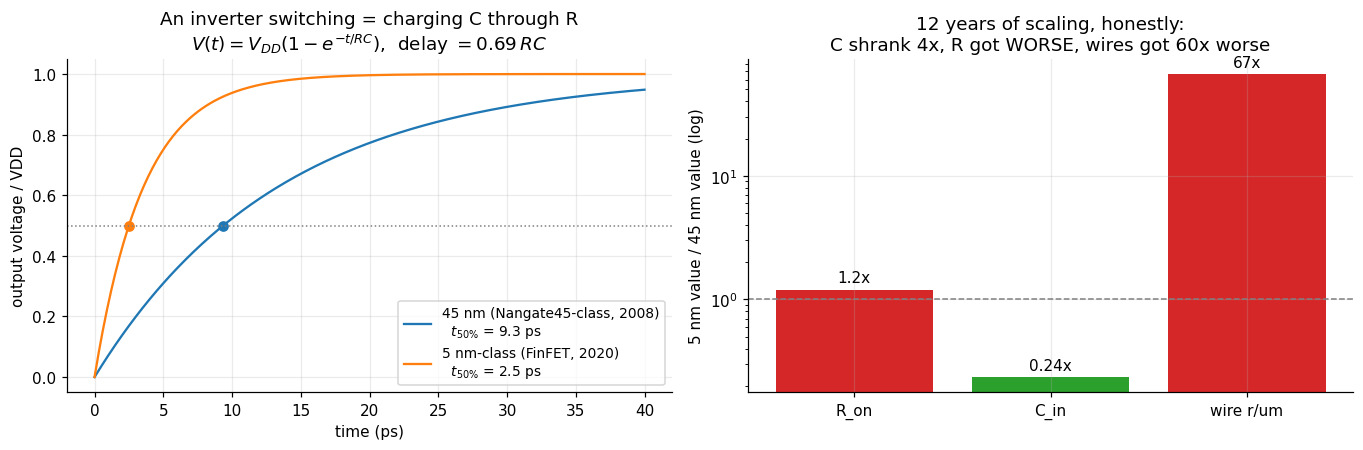

Memorize the asymmetry: scaling shrank C dramatically, barely improved R,
and made wires much worse. Sections 2-4 are consequences of this one chart.


In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt

# On Apple-Silicon Macs the Accelerate BLAS emits spurious matmul RuntimeWarnings.
warnings.filterwarnings("ignore", message=".*encountered in matmul")

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def show_table(headers, rows, floatfmt="{:.3f}"):
    '''Print a plain-text table (no pandas dependency).'''
    def fmt(v):
        if isinstance(v, float):
            return floatfmt.format(v)
        return str(v)
    str_rows = [[fmt(v) for v in row] for row in rows]
    widths = [max(len(h), *(len(r[i]) for r in str_rows)) for i, h in enumerate(headers)]
    line = "  ".join(h.ljust(w) for h, w in zip(headers, widths))
    print(line)
    print("-" * len(line))
    for r in str_rows:
        print("  ".join(v.ljust(w) for v, w in zip(r, widths)))


# Two reference technologies used throughout. These are ROUNDED RULES OF THUMB,
# not a self-consistent SPICE deck: 45nm values are anchored to the open
# Nangate45/FreePDK45 library (we read the actual Liberty file in section 6),
# 5nm-class values are public-literature estimates for a TSMC-N5-like FinFET node.
NODE = {
    "45 nm (Nangate45-class, 2008)": dict(
        VDD=1.1,            # V
        Ron=5e3,            # ohm, effective min-device on-resistance
        C_in=1.7e-15,       # F, min inverter input cap (matches INV_X1: 1.70 fF)
        C_par=1.0e-15,      # F, self-loading (drain) cap
        FO4=17e-12,         # s, fanout-of-4 inverter delay
        t_setup=40e-12, t_clk2q=80e-12, t_hold=5e-12,   # s, DFF characteristics
        r_wire=3.0,         # ohm/um, intermediate metal
        c_wire=0.2e-15,     # F/um  (roughly universal across nodes!)
    ),
    "5 nm-class (FinFET, 2020)": dict(
        VDD=0.75,
        Ron=6e3,            # R did NOT improve -- thin fins are resistive
        C_in=0.4e-15, C_par=0.2e-15,
        FO4=5e-12,
        t_setup=15e-12, t_clk2q=20e-12, t_hold=3e-12,
        r_wire=200.0,       # min-pitch Mx exploded (Cu scattering + barrier liner)
        c_wire=0.2e-15,
    ),
}

rows = []
for name, p in NODE.items():
    C_load = p["C_in"] + p["C_par"]                     # FO1: drive one copy of yourself
    t50 = 0.69 * p["Ron"] * C_load
    e_cycle = C_load * p["VDD"] ** 2                    # one full 0->1->0 cycle
    rows.append([name, p["VDD"], p["Ron"] / 1e3, C_load * 1e15,
                 t50 * 1e12, e_cycle * 1e15])
show_table(["node", "VDD (V)", "R_on (kOhm)", "C_FO1 (fF)", "0.69RC (ps)", "CV^2 (fJ)"],
           rows, floatfmt="{:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
t = np.linspace(0, 40e-12, 400)
for name, p in NODE.items():
    C_load = p["C_in"] + p["C_par"]
    RC = p["Ron"] * C_load
    v = 1 - np.exp(-t / RC)                             # normalized to VDD
    t50 = 0.69 * RC
    line, = axes[0].plot(t * 1e12, v, label=f"{name}\n  $t_{{50\\%}}$ = {t50*1e12:.1f} ps")
    axes[0].plot([t50 * 1e12], [0.5], "o", c=line.get_color())
axes[0].axhline(0.5, ls=":", c="gray", lw=1)
axes[0].set_xlabel("time (ps)")
axes[0].set_ylabel("output voltage / VDD")
axes[0].set_title("An inverter switching = charging C through R\n$V(t) = V_{DD}(1 - e^{-t/RC})$,  delay $= 0.69\\,RC$")
axes[0].legend(fontsize=9)

names = list(NODE)
ratios = {
    "R_on": NODE[names[1]]["Ron"] / NODE[names[0]]["Ron"],
    "C_in": NODE[names[1]]["C_in"] / NODE[names[0]]["C_in"],
    "wire r/um": NODE[names[1]]["r_wire"] / NODE[names[0]]["r_wire"],
}
bars = axes[1].bar(ratios.keys(), ratios.values(),
                   color=["#d62728", "#2ca02c", "#d62728"])
axes[1].axhline(1.0, ls="--", c="gray", lw=1)
axes[1].set_yscale("log")
axes[1].set_ylabel("5 nm value / 45 nm value (log)")
axes[1].set_title("12 years of scaling, honestly:\nC shrank 4x, R got WORSE, wires got 60x worse")
for b, v in zip(bars, ratios.values()):
    axes[1].text(b.get_x() + b.get_width() / 2, v * 1.15, f"{v:.2g}x",
                 ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print("Memorize the asymmetry: scaling shrank C dramatically, barely improved R,")
print("and made wires much worse. Sections 2-4 are consequences of this one chart.")

## 2. Delay from first principles

### 2.1 $0.69\,RC$ is ~80% of digital timing

When a gate switches, its on-transistor $R$ charges the load $C$ (receiver gate caps + wire). The output
follows $V(t) = V_{DD}(1 - e^{-t/RC})$, so the 50%-crossing delay is $t_{50} = RC\ln 2 \approx 0.69\,RC$.
Everything a static timing analyzer does is an elaborate, table-driven, slew-aware version of $0.69\,RC$
summed along paths (we will read those exact tables out of a real library in §6.3). For RC *trees* (a driver
feeding branching wire), the **Elmore delay** generalizes it: walk the resistive path, multiply each $R$ by all
the capacitance downstream of it, and sum. Elmore is the fast estimator inside placement/routing tools — and,
not coincidentally, a favorite feature in ML timing models: additive, cheap, roughly monotone in the truth.

### 2.2 Logical effort: why "size each stage ~4×"

Normalize delay as $d = g\,h + p$ (in units of $\tau$, the technology time constant ≈ RC of a minimum inverter:
~3–4 ps at 45 nm, ~1 ps at 5 nm-class):

- $h = C_{out}/C_{in}$ — **electrical effort** (fanout): delay is *linear* in how much load you drive;
- $g$ — **logical effort** of the topology: INV 1, NAND2 4/3, NOR2 5/3 (the PMOS stack tax — why synthesis
  prefers NAND-heavy mappings), XOR2 ≈ 4;
- $p$ — parasitic self-delay ($p_{inv} \approx 1$).

For a chain driving a total effort $F = C_{big}/C_{small}$, total delay is minimized when each stage bears
equal effort, and the optimum per-stage effort is ≈ 3.6–4. That single result explains: why libraries ship
X1/X2/X4/X8 drive strengths, why buffer chains driving pads look geometric, and why adding a gate can *speed
a path up*.

### 2.3 FO4: the universal ruler

**FO4** = delay of an inverter driving 4 copies of itself ($d = 1\cdot4 + 1 = 5\tau$). Quote path depths in FO4
and they become node-independent. Anchors: ~80–90 ps at 180 nm, **~17 ps at 45 nm**, ~5 ps at 5 nm-class,
~4 ps at 3 nm (sub-16 nm values are estimates — foundries don't publish). A sane pipeline stage is 25–35 FO4 of
logic; a 64-bit adder is 7–12 FO4; Pentium 4 pushed ~16 FO4/stage and died of power (§5).


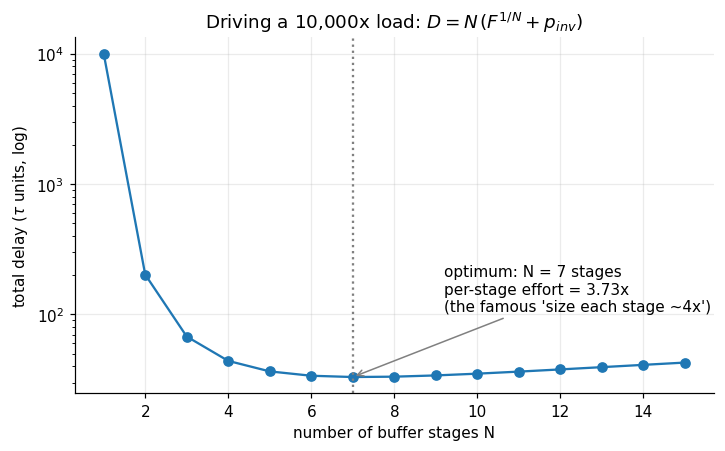

45 nm (Nangate45-class, 2008):  tau = 3.4 ps  ->  optimal chain delay = 113 ps  (33.1 tau)
5 nm-class (FinFET, 2020):  tau = 1.0 ps  ->  optimal chain delay = 33 ps  (33.1 tau)

One stage instead would take F + p = 10001 tau -- 300x slower.
This is why synthesis inserts buffers: adding gates can make paths faster.


In [2]:
# Logical effort: total delay vs number of stages for a big fanout task.
# Task: drive C_big/C_small = 10,000 (e.g. a 10 pF output net from a ~1 fF gate).
F = 1e4
p_inv = 1.0
Ns = np.arange(1, 16)
D_tau = np.array([N * (F ** (1 / N) + p_inv) for N in Ns])

best = Ns[np.argmin(D_tau)]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(Ns, D_tau, "o-")
ax.axvline(best, ls=":", c="gray")
ax.annotate(f"optimum: N = {best} stages\nper-stage effort = {F**(1/best):.2f}x\n"
            f"(the famous 'size each stage ~4x')",
            xy=(best, D_tau.min()), xytext=(best + 2.2, D_tau.min() * 3.2),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10)
ax.set_yscale("log")
ax.set_xlabel("number of buffer stages N")
ax.set_ylabel(r"total delay ($\tau$ units, log)")
ax.set_title(r"Driving a 10,000x load: $D = N\,(F^{1/N} + p_{inv})$")
plt.show()

for name, p in NODE.items():
    tau_ps = p["FO4"] / 5 * 1e12          # FO4 = 5 tau
    print(f"{name}:  tau = {tau_ps:.1f} ps  ->  optimal chain delay = "
          f"{D_tau.min() * tau_ps:.0f} ps  ({D_tau.min():.1f} tau)")
print("\nOne stage instead would take F + p =", f"{F + p_inv:.0f} tau -- 300x slower.")
print("This is why synthesis inserts buffers: adding gates can make paths faster.")

### 2.4 Wires: the part that stopped scaling

Per unit length, a wire has $r = \rho/(w\,t)$ and $c \approx 0.2$ fF/µm — and the remarkable fact is that **$c$
is roughly a universal constant across every node and layer** (capacitance depends on geometry *ratios*), while
$r$ explodes as $1/k^2$ when width and thickness both shrink — made worse by copper's effective resistivity
rising 2–5× in nm-scale wires (surface/grain-boundary scattering + a non-scaling barrier liner).

An unbuffered wire of length $L$ has delay $t \approx 0.38\,r c\,L^2$ — **quadratic**, because total R and
total C both grow with $L$. The fix is **repeaters**: cut the wire into $N$ segments with buffers between,
making delay linear in $L$. The price: in a modern SoC, a large fraction of all cells are buffers/inverters
inserted purely for wires and hold fixing.

Consequences that shape everything above this layer: physical design became **placement-dominated** (where
cells sit matters as much as what they are — one core reason RTL-stage PPA prediction is hard without physical
hints); microarchitecture went hierarchical (mesh NoCs, clusters, chiplets); and crossing a large die now takes
>10 cycles at 2 GHz even with optimal buffering.


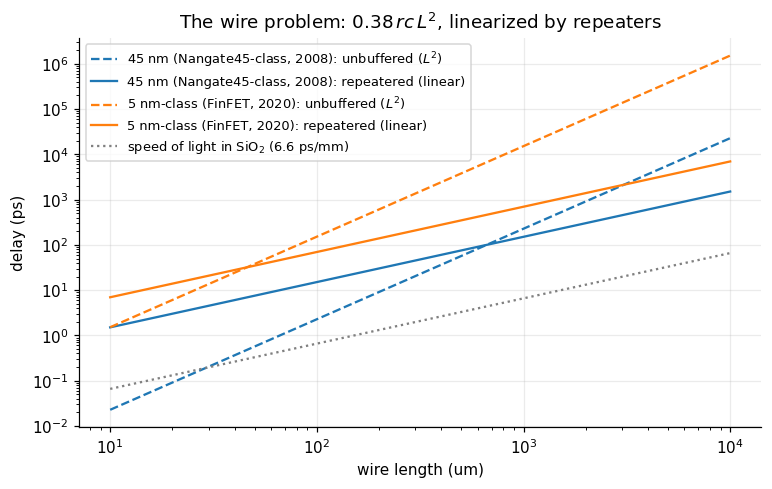

1 mm of 45nm intermediate metal, unbuffered: 228 ps  (~13 FO4 -- a full pipeline stage burned on 1 mm of travel)
Same 1 mm repeatered: 151 ps -> ~151 ps/mm, still ~20x slower than light in the dielectric.
On 5nm minimum-pitch metal, 1 mm unbuffered would be ~10 ns: simply never routed that way.


In [3]:
# Unbuffered L^2 wire delay vs repeatered (linearized) delay.
L_um = np.logspace(1, 4, 200)          # 10 um .. 10 mm

fig, ax = plt.subplots(figsize=(8, 4.6))
for (name, p), t_buf in zip(NODE.items(), [25e-12, 8e-12]):
    a = 0.38 * p["r_wire"] * p["c_wire"]            # s / um^2
    t_unbuf = a * L_um ** 2
    t_rep = 2 * L_um * np.sqrt(a * t_buf)           # optimally segmented
    line, = ax.plot(L_um, t_unbuf * 1e12, ls="--", label=f"{name}: unbuffered ($L^2$)")
    ax.plot(L_um, t_rep * 1e12, c=line.get_color(), label=f"{name}: repeatered (linear)")
# speed of light in SiO2 for shame:
ax.plot(L_um, L_um * 6.6e-3, c="gray", ls=":", label="speed of light in SiO$_2$ (6.6 ps/mm)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("wire length (um)")
ax.set_ylabel("delay (ps)")
ax.set_title("The wire problem: $0.38\\,rc\\,L^2$, linearized by repeaters")
ax.legend(fontsize=8.5, loc="upper left")
plt.show()

p45 = NODE["45 nm (Nangate45-class, 2008)"]
a45 = 0.38 * p45["r_wire"] * p45["c_wire"]
print(f"1 mm of 45nm intermediate metal, unbuffered: {a45 * 1000**2 * 1e12:.0f} ps"
      f"  (~{a45 * 1000**2 / p45['FO4']:.0f} FO4 -- a full pipeline stage burned on 1 mm of travel)")
print(f"Same 1 mm repeatered: {2 * 1000 * np.sqrt(a45 * 25e-12) * 1e12:.0f} ps "
      f"-> ~{2 * np.sqrt(a45 * 25e-12) * 1e15:.0f} ps/mm, still ~20x slower than light in the dielectric.")
print("On 5nm minimum-pitch metal, 1 mm unbuffered would be ~10 ns: simply never routed that way.")

## 3. Time: registers, the clock, and static timing analysis

### 3.1 Why flip-flops exist

Combinational logic is a race: outputs glitch and settle at input- and temperature-dependent times. To build a
*system* you need to agree on when signals are valid. The solution: chop computation into stages separated by
**registers** that all sample on a **clock edge**. Between edges logic may glitch freely; at the edge, whatever
has settled becomes committed state. **Time becomes discrete** — the single most important abstraction in
hardware. RTL ("register-transfer level") is named for exactly this world-view:

$$\text{state}' = f(\text{state}, \text{inputs}) \quad\text{(combinational cloud)},\qquad
\text{state} \leftarrow \text{state}' \quad\text{(registers, on the clock edge)}.$$

A flip-flop is two latches back-to-back (master + slave); from that structure fall out its three parameters:

- **setup time** $t_{setup}$: D must arrive early enough to regenerate in the master before the edge slams it shut
  (Nangate45 DFF_X1: ~16–100 ps depending on slew);
- **hold time** $t_{hold}$: D must stay stable briefly *after* the edge. Crucially, a hold violation is a race
  between two edges of the *same* clock — **it cannot be fixed by slowing the clock down**. A hold-broken chip is
  dead at every frequency, which is why hold is checked with paranoid margins and fixed by inserting delay buffers;
- **clock-to-Q** $t_{clk2q}$: edge → new value visible at Q.

If D changes inside the setup/hold window, the master's cross-coupled pair can hang **metastable** — balanced at
its unstable equilibrium for an exponentially-distributed time. It cannot be eliminated (a continuous system
deciding between two states must have a balance point), only made astronomically rare: a second synchronizer
flop multiplies MTBF by $e^{t_{slack}/\tau_{reg}}$ — from hours to geological time.

### 3.2 The two timing checks

$$T_{clk} \ \ge\ t_{clk2q} + t_{logic,max} + t_{setup} + \text{skew margin} \qquad \text{(setup: sets } f_{max})$$
$$t_{clk2q,min} + t_{logic,min} \ \ge\ t_{hold} + \text{skew} \qquad \text{(hold: period-independent)}$$

**Static timing analysis (STA)** verifies these for *every* path without simulation — a longest-path graph
traversal over the netlist. Its two headline outputs are the numbers every PPA paper predicts:
**WNS** (worst negative slack: the single worst path — sets $f_{max}$) and **TNS** (total negative slack summed
over violating endpoints: how much work is left). Commercial signoff STA (Synopsys PrimeTime) adds corners,
crosstalk, and statistical on-chip-variation models — but the core is what we now build in 30 lines.


In [4]:
# A toy static timing analyzer, run on a real circuit shape: a ripple-carry adder
# between two register banks. Gate delays are loaded 45nm-ish values (ps).
GATE_DELAY_PS = {"XOR2": 45.0, "AND2": 30.0, "OR2": 30.0}


def ripple_adder(nbits):
    '''Netlist as {gate_name: (type, [fanin names])}, in topological order.'''
    gates = {}
    for i in range(nbits):
        gates[f"p{i}"] = ("XOR2", [f"a{i}", f"b{i}"])        # propagate
        gates[f"g{i}"] = ("AND2", [f"a{i}", f"b{i}"])        # generate
        gates[f"s{i}"] = ("XOR2", [f"p{i}", f"c{i}"])        # sum bit
        gates[f"t{i}"] = ("AND2", [f"p{i}", f"c{i}"])
        gates[f"c{i+1}"] = ("OR2", [f"g{i}", f"t{i}"])       # carry out
    inputs = [f"a{i}" for i in range(nbits)] + [f"b{i}" for i in range(nbits)] + ["c0"]
    endpoints = [f"s{i}" for i in range(nbits)] + [f"c{nbits}"]
    return gates, inputs, endpoints


def sta(gates, inputs, endpoints, T_clk_ps, t_clk2q=80.0, t_setup=40.0, skew=50.0):
    '''Longest-path arrival propagation; returns (arrival, slack, WNS, TNS, fmax_GHz).'''
    arrival = {pi: 0.0 for pi in inputs}
    for name, (typ, fanin) in gates.items():
        arrival[name] = max(arrival[f] for f in fanin) + GATE_DELAY_PS[typ]
    slack = {ep: T_clk_ps - (t_clk2q + arrival[ep] + t_setup + skew) for ep in endpoints}
    wns = min(slack.values())
    tns = sum(min(0.0, s) for s in slack.values())
    worst_arr = max(arrival[ep] for ep in endpoints)
    fmax_GHz = 1e3 / (t_clk2q + worst_arr + t_setup + skew)
    return arrival, slack, wns, tns, fmax_GHz


# --- setup analysis of an 8-bit adder at a 2 GHz target -------------------------
gates, inputs, endpoints = ripple_adder(8)
T = 500.0                                     # ps  (2 GHz)
arrival, slack, wns, tns, fmax = sta(gates, inputs, endpoints, T)

worst = sorted(endpoints, key=lambda e: slack[e])[:5]
show_table(["endpoint", "arrival (ps)", "slack (ps)"],
           [[e, arrival[e], slack[e]] for e in worst], floatfmt="{:+.1f}")
print(f"\n@2 GHz:  WNS = {wns:+.0f} ps   TNS = {tns:+.0f} ps   "
      f"->  this block only closes timing at fmax = {fmax*1e3:.0f} MHz")
print("The critical path is the carry chain -- every ripple adder's curse.")

# --- hold analysis: note it does not involve T_clk at all -----------------------
min_arr = min(arrival[ep] for ep in endpoints)
hold_slack = 40.0 + min_arr - (5.0 + 50.0)    # clk2q_min + shortest logic - (t_hold + skew)
print(f"\nHold slack on the shortest path: {hold_slack:+.0f} ps  "
      "(same number at 2 GHz, 1 GHz, or 1 Hz: hold is period-independent).")

# --- fmax vs operand width: remember this curve for the kimi-chip story ---------
rows = []
for nb in [4, 8, 12, 16, 24, 32]:
    g, i_, e_ = ripple_adder(nb)
    *_, f = sta(g, i_, e_, T)
    rows.append([nb, f * 1e3])
show_table(["adder width (bits)", "fmax (MHz)"], rows, floatfmt="{:.0f}")
print("\nA 24-bit accumulate loop is ~1.8x slower than a 12-bit one -- file this away:")
print("it is exactly the bottleneck kimi-chip's X4 iteration found and removed (section 8).")

endpoint  arrival (ps)  slack (ps)
----------------------------------
c8        +525.0        -195.0    
s7        +510.0        -180.0    
s6        +450.0        -120.0    
s5        +390.0        -60.0     
s4        +330.0        +0.0      

@2 GHz:  WNS = -195 ps   TNS = -555 ps   ->  this block only closes timing at fmax = 1439 MHz
The critical path is the carry chain -- every ripple adder's curse.

Hold slack on the shortest path: +75 ps  (same number at 2 GHz, 1 GHz, or 1 Hz: hold is period-independent).
adder width (bits)  fmax (MHz)
------------------------------
4                   2198      
8                   1439      
12                  1070      
16                  851       
24                  604       
32                  468       

A 24-bit accumulate loop is ~1.8x slower than a 12-bit one -- file this away:
it is exactly the bottleneck kimi-chip's X4 iteration found and removed (section 8).


## 4. Pipelining: buying frequency with registers

If the combinational cloud between two registers is $N_{FO4}$ deep, then
$f_{max} = 1/(t_{clk2q} + N_{FO4}\cdot FO4 + t_{setup} + \text{margin})$. Cut the cloud in half with a register
and frequency (nearly) doubles — at the cost of one cycle of latency and some flop area/power. This is
**pipelining**, and it has diminishing returns for a fixed physical reason: the *sequencing overhead*
$t_{clk2q} + t_{setup} + \text{margin}$ is a fixed tax per stage. At 45 nm the tax is ~170 ps; at 5 GHz in a
5 nm-class node the tax alone eats 20–30% of the 200 ps cycle — one reason the GHz race ended and designers
now spend transistors on width (cores, SIMD, accelerators) instead of depth.

The kimi-chip project is a textbook demonstration on real tools (details in §8):

- **X1–X3 plateau at 468 MHz**: a wide (24-bit) accumulator adder sat in the every-cycle loop — compare our
  toy adder table above;
- **X4, the 2× jump**: accumulate in a *narrow 12-bit* register every cycle, fold into the wide 24-bit
  accumulator only once per 16 products — the wide adder leaves the critical loop (classic *hierarchical
  accumulation*);
- **X5, the last 15%**: register the multiplier output (multiply → register → accumulate), split folds into
  registered slices — classic pipelining, straight to **1047 MHz**, 10.5× the original chip's 100 MHz.


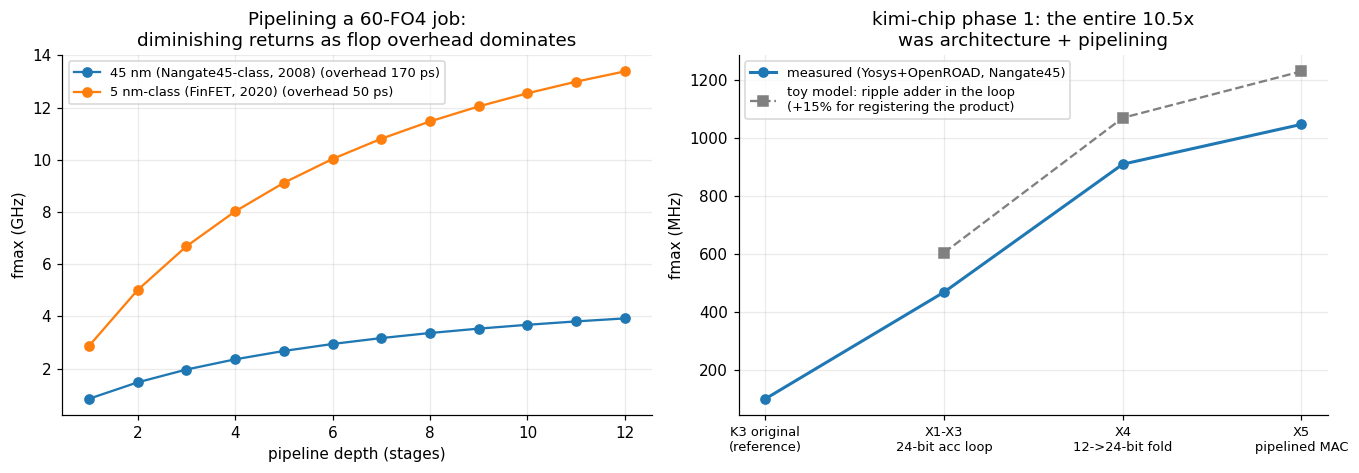

Jump ratios, measured vs toy model:
transition                       measured  toy ripple model
-----------------------------------------------------------
24-bit loop -> 12-bit fold (X4)  1.94x     1.77x           
+ register the product (X5)      1.15x     1.15x           

A 30-line delay model predicts the shape of a real place-and-route outcome --
that is the entire thesis of RTL-stage PPA estimation (section 11).


In [5]:
# fmax vs pipeline depth for a fixed job (60 FO4 of total logic), both nodes.
total_fo4 = 60
depths = np.arange(1, 13)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for name, p in NODE.items():
    overhead = (p["t_clk2q"] + p["t_setup"]) * 1e12 + 50 * (p["FO4"] / 17e-12)  # skew scales w/ node
    fmax = 1e3 / (overhead + total_fo4 / depths * p["FO4"] * 1e12)              # GHz
    axes[0].plot(depths, fmax, "o-", label=f"{name} (overhead {overhead:.0f} ps)")
axes[0].set_xlabel("pipeline depth (stages)")
axes[0].set_ylabel("fmax (GHz)")
axes[0].set_title("Pipelining a 60-FO4 job:\ndiminishing returns as flop overhead dominates")
axes[0].legend(fontsize=8.5)

# The measured kimi-chip phase-1 arc vs our toy ripple-adder model.
stages = ["K3 original\n(reference)", "X1-X3\n24-bit acc loop", "X4\n12->24-bit fold",
          "X5\npipelined MAC"]
measured = [100, 468.201, 909.621, 1047]
axes[1].plot(stages, measured, "o-", lw=2, label="measured (Yosys+OpenROAD, Nangate45)")

def adder_fmax_mhz(nb):
    g, i_, e_ = ripple_adder(nb)
    *_, f = sta(g, i_, e_, 500.0)
    return f * 1e3

toy = [None, adder_fmax_mhz(24), adder_fmax_mhz(12), adder_fmax_mhz(12) * 1.15]
axes[1].plot(stages[1:], toy[1:], "s--", c="gray",
             label="toy model: ripple adder in the loop\n(+15% for registering the product)")
axes[1].set_ylabel("fmax (MHz)")
axes[1].set_title("kimi-chip phase 1: the entire 10.5x\nwas architecture + pipelining")
axes[1].legend(fontsize=8.5)
plt.setp(axes[1].get_xticklabels(), fontsize=8.5)
plt.tight_layout()
plt.show()

print("Jump ratios, measured vs toy model:")
show_table(["transition", "measured", "toy ripple model"],
           [["24-bit loop -> 12-bit fold (X4)", 909.621 / 468.201, toy[2] / toy[1]],
            ["+ register the product (X5)",     1047 / 909.621,    1.15]],
           floatfmt="{:.2f}x")
print("\nA 30-line delay model predicts the shape of a real place-and-route outcome --")
print("that is the entire thesis of RTL-stage PPA estimation (section 11).")

## 5. Power from first principles

### 5.1 Dynamic power: $P = \alpha\,C\,V^2 f$

Charging a node to $V_{DD}$ draws $Q V_{DD} = C V_{DD}^2$ from the supply; exactly half is dissipated in the
pull-up resistance on the way up (the ½ is independent of R — do the integral), half is stored on C and burned
in the pull-down on the way back. **Convention used everywhere in this notebook: $CV^2$ per full 0→1→0 cycle,
$\tfrac{1}{2}CV^2$ per edge.** With $\alpha$ = activity factor (fraction of cycles a node completes a full
cycle: ~0.05–0.15 for logic, 0.5 for a random data bit, **1.0 for the clock**):

$$P_{dyn} = \alpha\, C_{total}\, V_{DD}^2\, f$$

The $V^2$ is the lever (hence DVFS); the $\alpha$ term is why **clock gating** is the #1 power technique; and
because wire capacitance dominates gate capacitance on most nets, "power" is mostly *moving charge across
distance, on schedule* — interconnect ≈ 50% of dynamic power (Magen et al., SLIP 2004), clock distribution
alone commonly 25–40%.

### 5.2 Leakage, $V_t$ flavors, and the Boltzmann tyranny

Below $V_t$ a MOSFET is an exponential dial, not a switch: subthreshold current falls at best
**60 mV/decade at 300 K** ($kT/q \cdot \ln 10 \approx 59.6$ mV — thermodynamics, not engineering). Every
~60–80 mV you lower $V_t$ buys ~10–15% speed and ~5–10× leakage. Libraries therefore ship each cell in 2–4
**$V_t$ flavors** (ULVT/LVT/SVT/HVT); synthesis puts leaky-fast LVT only on critical paths. Gate-oxide
tunneling — the other leakage — was fixed at the 45 nm generation by high-k metal gate (HfO₂, k≈20 vs 3.9:
physically thicker yet capacitively stronger; a rare clean win).

### 5.3 The end of Dennard scaling → the shape of all modern hardware

Dennard (1974): shrink dimensions and voltage by 0.7×/generation and power *density* stays constant — the free
lunch behind 1 MHz → 3 GHz. It died ~2005 when $V_{DD}$ stopped scaling (leakage floor, §5.2): nominal supply
has been stuck at ~0.65–1.0 V for two decades. The forced chain of consequences: **power wall** → stop raising
$f$, go **multicore** (2005: Pentium D, Athlon 64 X2) → per-transistor energy now falls slower than density
rises → can't switch everything at once: **dark silicon** (Esmaeilzadeh, ISCA 2011) → fill dark area with
**specialized accelerators** powered only when used → the NPU/TPU/GPU era, where PPA-per-workload, not
frequency, is the objective. Meanwhile flagship chips (350–500 W CPUs, 700–1400 W training GPUs) are now gated
by power *delivery* and cooling — hence backside power (Intel PowerVia in 18A; TSMC A16 Super Power Rail).

Energy anchors (Horowitz, ISSCC 2014, ~45 nm): int32 add 0.1 pJ, fp32 multiply 3.7 pJ, 8 KB SRAM read 5 pJ,
**off-chip DRAM read ~1.3–2.6 nJ per access** — the 100–1000× arithmetic-vs-memory gap under every ML-hardware
talking point (systolic arrays, operand reuse, HBM).


45 nm (Nangate45-class, 2008): 1e+08 gates x alpha=0.1 x 2.0 fF x (1.1 V)^2 x 2 GHz = 48 W
5 nm-class (FinFET, 2020): 1e+09 gates x alpha=0.1 x 0.5 fF x (0.75 V)^2 x 3 GHz = 84 W
~50 W for a 45nm-era CPU, ~85 W for a 5nm-era one: the right order of magnitude,
from four numbers. The V^2 lever: (1.1/0.75)^2 = 2.15x -- why DVFS exists.



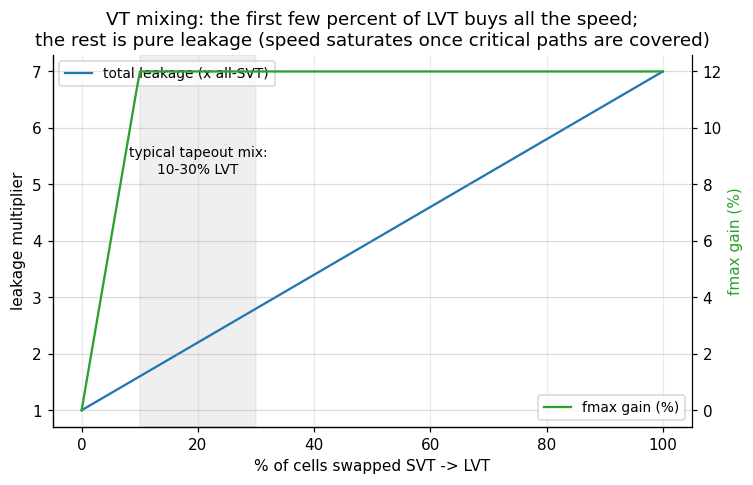

This 'VT mix' is a knob synthesis/P&R turn automatically -- and a line item
in every PPA report. One more surrogate your models learn to predict.


In [6]:
# (a) A whole-chip dynamic power estimate from four numbers.
# C_node = average switched capacitance per gate NODE (gate input + share of wire).
for name, VDD, n_gates, f, C_node in [
    ("45 nm (Nangate45-class, 2008)", 1.1,  1e8, 2e9, 2.0e-15),
    ("5 nm-class (FinFET, 2020)",     0.75, 1e9, 3e9, 0.5e-15),
]:
    P = 0.1 * n_gates * C_node * VDD ** 2 * f
    print(f"{name}: {n_gates:.0e} gates x alpha=0.1 x {C_node*1e15:.1f} fF x "
          f"({VDD} V)^2 x {f/1e9:.0f} GHz = {P:.0f} W")
print("~50 W for a 45nm-era CPU, ~85 W for a 5nm-era one: the right order of magnitude,")
print("from four numbers. The V^2 lever:", f"(1.1/0.75)^2 = {(1.1/0.75)**2:.2f}x -- why DVFS exists.\n")

# (b) The VT-mix tradeoff: sweep the fraction of cell width moved from SVT to LVT.
#     Model: one VT step = +12% gate speed, x7 leakage; only ~10% of paths are critical.
lvt_frac = np.linspace(0, 1, 200)
leakage = (1 - lvt_frac) + lvt_frac * 7.0            # normalized to all-SVT
crit_frac = 0.10
speed_gain = 1 + 0.12 * np.minimum(1.0, lvt_frac / crit_frac)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(lvt_frac * 100, leakage, label="total leakage (x all-SVT)")
ax2 = ax.twinx()
ax2.plot(lvt_frac * 100, (speed_gain - 1) * 100, c="#2ca02c", label="fmax gain (%)")
ax2.spines["right"].set_visible(True)
ax.axvspan(10, 30, alpha=0.12, color="gray")
ax.annotate("typical tapeout mix:\n10-30% LVT", xy=(20, 5.2), ha="center", fontsize=9)
ax.set_xlabel("% of cells swapped SVT -> LVT")
ax.set_ylabel("leakage multiplier")
ax2.set_ylabel("fmax gain (%)", color="#2ca02c")
ax.set_title("VT mixing: the first few percent of LVT buys all the speed;\n"
             "the rest is pure leakage (speed saturates once critical paths are covered)")
ax.legend(loc="upper left", fontsize=9)
ax2.legend(loc="lower right", fontsize=9)
plt.show()

print("This 'VT mix' is a knob synthesis/P&R turn automatically -- and a line item")
print("in every PPA report. One more surrogate your models learn to predict.")

## 6. The design flow: what actually happens between spec and silicon

### 6.1 The compiler that costs $30M to run once

The ASIC flow is a giant, lossy, multi-stage compiler:

```
C++ program:  source -> AST -> IR -> optimized IR -> machine code -> binary
Chip:         spec -> microarchitecture -> RTL -> gate netlist -> placed & routed netlist -> GDSII
```

With one crucial difference: each "compile" stage takes hours-to-days, the final "run" (fabrication) takes
**~3–4 months and a mask set costing $1M (28 nm) to $30–40M (3/2 nm)** — and there is no patch mechanism. A bug
that escapes to silicon is a *respin*. This single asymmetry explains the industry's culture: why verification
consumes more engineer-hours than design, why there are five independent signoff checks, why margins are
stacked everywhere.

**The abstraction stack** (each layer hides the one below behind a *characterized contract*):

| Layer | Object | Contract exposed upward |
|---|---|---|
| Physics | electrons, fields | band structure |
| Device | transistor (FinFET → GAA) | I-V curves, SPICE models |
| Circuit | standard cell, SRAM bitcell | Boolean function + timing/power tables (**.lib**) |
| Gate | netlist of cells | Boolean network with delays |
| **RTL** | registers + combinational transfer | cycle-accurate behavior |
| Microarchitecture | pipelines, caches, predictors | IPC, latency, bandwidth |
| ISA | x86-64, ARMv9, RISC-V | the software-visible machine |

The `.lib` file is literally "the transistor layer compressed into lookup tables" — we open one in §6.4.
Orthogonal to the stack is the **spatial hierarchy**: standard cell (~1 µm²) → **block/tile** (the unit of
physical-design ownership, ~50K–5M placed instances, 0.1–5 mm² — an FP unit, a NoC router, one GPU CU/SM slice,
replicated 100+ times) → subsystem → SoC top → package (chiplets extend the hierarchy past the die edge).
"Tile-level PPA estimation" is named for exactly this unit.

**Why not just use an FPGA?** You can — that's what prototyping is. But programmable interconnect costs
roughly **35× area, 3–4× delay, ~14× dynamic power** vs standard cells for the same logic (Kuon & Rose, TCAD
2007). FPGAs win on NRE ($0 masks) and time; ASICs win on everything per-unit. Volume decides.

**Scale check** (fact-of-life numbers, all estimates): a flagship CPU/GPU generation is a 3–5 year, pipelined,
several-hundred-to-few-thousand-engineer effort; total design cost by node (IBS estimates): ~$50M at 28 nm,
~$300M at 7 nm, ~$540M at 5 nm, **~$725M at 2 nm**. That ladder is why only ~a dozen companies still tape out
leading-edge dies (we model it in §10).

### 6.2 RTL: where the human intent enters

RTL describes hardware as **registers plus the combinational functions between them** — the sweet spot where
the clock exists but transistor physics doesn't. For an ML engineer: RTL is the computation-graph level —
above kernels (gates), below the architecture prose (µarch spec). You declare what each cycle computes; the
tools choose how.

```systemverilog
// Combinational: recompute whenever inputs change  -> becomes gates
always_comb begin
    sum = a + b;                       // an adder
    y   = sel ? sum : c;               // a mux
end

// Sequential: capture on clock edge  -> becomes flip-flops
always_ff @(posedge clk or negedge rst_n) begin
    if (!rst_n) count <= '0;
    else        count <= count + 1;    // non-blocking (<=): simultaneous update
end
```

SystemVerilog is two languages in one file: a **synthesizable subset** (`always_ff`/`always_comb`, static
loops, generate blocks — anything with an obvious structural interpretation) and a simulation-only testbench
language (delays, classes, constrained randomization). RTL designers spend their time not on typing (a CPU
block is only 5–50K lines) but on *making timing* — restructuring logic so critical paths fit the cycle — plus
interface negotiation, clock gating (>90% of flops should be gateable), and clock-domain crossings. Check-in
gates: lint + CDC clean (Synopsys VC SpyGlass, Siemens Questa CDC, Real Intent Meridian CDC).

### 6.3 Verification: more than half of everything

Nothing else in the flow checks *intent* — synthesis faithfully compiles your bugs. A block with 10K flops has
$2^{10000}$ states; you cannot enumerate, only sample cleverly and prove locally:

1. **Constrained-random verification**: describe the legal input space; randomize within it, millions of cycles
   nightly on 10K–100K-core farms. Humans are bad at imagining bug scenarios; volume finds the collisions.
   Methodology standard: **UVM** (agents/monitors/scoreboards vs a C++ reference model).
2. **Coverage** is verification's loss function: code coverage (necessary, insufficient) + *functional*
   coverage ("did we ever see an eviction concurrent with an ECC error?"). Signoff = coverage plan 100% hit or
   waived, over many seeds.
3. **Formal verification** (Cadence JasperGold, Synopsys VC Formal): mathematically *prove* properties of
   blocks — arbiters, FIFOs, security paths (famous since the 1994 Pentium FDIV bug: $475M).
4. **Equivalence checking** proves netlist ≡ RTL after every transformation (Formality/Conformal) — why nobody
   re-simulates gate netlists.
5. **Emulation** (Cadence Palladium, Synopsys ZeBu, Siemens Veloce — $1–10M+ boxes): the RTL compiled onto
   special hardware at ~MHz, to boot operating systems months before silicon.

Industry reality (Siemens/Wilson Research 2024 study): verification engineers now *outnumber* designers
(~1.5–2:1 planning ratio; 60–70% of project effort is the common planning number), ~47% of their time goes to
debug, and **first-silicon success has fallen to roughly the mid-teens percent** — ~85% of ASICs need at least
one respin, functional bugs leading. The next cell shows *why* it never feels done.


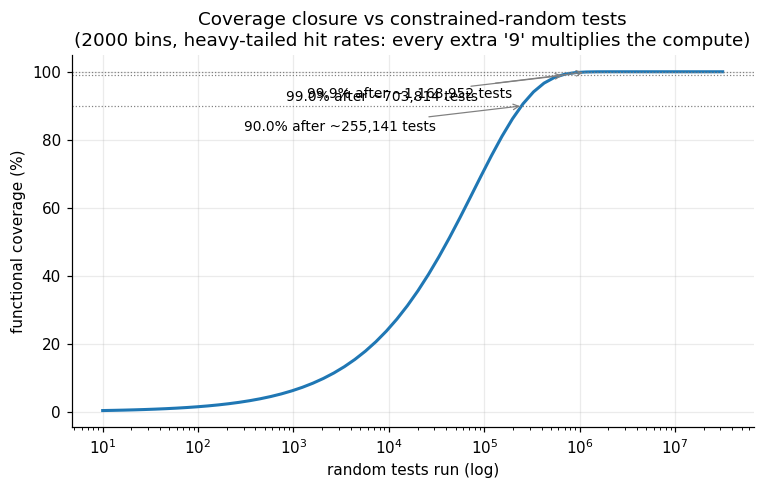

Going from 90% to 99.9% coverage costs ~5x more simulation than reaching 90% did.
This curve is why regression farms have 100k cores, why 'are we done?' is a
statistical question, and why formal proofs are priceless where they apply.


In [7]:
# Why coverage closure has brutal diminishing returns: rare scenarios are a
# heavy-tailed coupon-collector problem. 2000 coverage bins, hit probability ~ Zipf.
n_bins = 2000
p = np.arange(1, n_bins + 1, dtype=float) ** -1.5    # heavy tail: rare corner cases
p /= p.sum()                                   # bin i hit w.p. p_i per random test

T = np.logspace(1, 7.5, 60)                    # number of random tests
coverage = np.array([np.mean(1 - (1 - p) ** t) for t in T])

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.semilogx(T, coverage * 100, lw=2)
for target in [0.90, 0.99, 0.999]:
    t_hit = T[np.searchsorted(coverage, target)]
    ax.axhline(target * 100, ls=":", c="gray", lw=0.8)
    ax.annotate(f"{target:.1%} after ~{t_hit:,.0f} tests",
                xy=(t_hit, target * 100), xytext=(t_hit * 0.0012, target * 100 - 7.5),
                fontsize=9, arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
ax.set_xlabel("random tests run (log)")
ax.set_ylabel("functional coverage (%)")
ax.set_title("Coverage closure vs constrained-random tests\n"
             "(2000 bins, heavy-tailed hit rates: every extra '9' multiplies the compute)")
plt.show()

t90 = T[np.searchsorted(coverage, 0.90)]
t999 = T[np.searchsorted(coverage, 0.999)]
print(f"Going from 90% to 99.9% coverage costs ~{t999/t90:.0f}x more simulation than "
      "reaching 90% did.")
print("This curve is why regression farms have 100k cores, why 'are we done?' is a")
print("statistical question, and why formal proofs are priceless where they apply.")

### 6.4 Logic synthesis: RTL → gates, meeting the technology

Synthesis is the first stage where the design touches physics. Inputs and outputs:

| Direction | File | Content |
|---|---|---|
| in | `.sv` / `.v` | the RTL |
| in | `.lib` (Liberty) | per-cell delay/power as 2-D tables of (input slew × output load), one file per PVT corner |
| in | `.sdc` | constraints (Tcl): `create_clock -period 0.5`, I/O delays, false paths |
| out | gate-level netlist `.v` | structural Verilog: `NAND2_X2 u42 (.A1(n17), ...)` |
| out | reports | **WNS / TNS / area / power — the labels your PPA models train on** |

Three phases: **elaboration** (RTL → generic netlist; adders/muxes inferred, datapath architectures chosen —
ripple vs carry-lookahead vs Kogge-Stein per timing budget), **logic optimization** (technology-independent
Boolean rewriting: the open-source lineage is Berkeley's SIS → ABC, which powers Yosys), and **technology
mapping** (cover the Boolean network with real library cells, choosing drive strengths and $V_t$ flavors).
Modern tools are *physical-synthesis* engines using real placement estimates, because at ≤16 nm wire delay
rivals gate delay and wireload guessing correlates terribly. Tools: Synopsys Design Compiler / Fusion Compiler,
Cadence Genus, open-source **Yosys + ABC**. Runtime: 2–12 h for a 1–3M-instance block — the probe your
seconds-scale PPA predictor wants to replace.

Here is what the technology half actually looks like — a genuine excerpt from the **Nangate45 Liberty file**
shipped with OpenROAD (the exact library kimi-chip used; delays in ns, capacitance in fF):

```
cell (INV_X1) {
  area : 0.532000;
  pin (A)  { capacitance : 1.700230; }       /* 1.7 fF -- our NODE table's C_in! */
  pin (ZN) {
    function : "!A";
    max_capacitance : 60.730000;
    timing () {
      cell_rise(Timing_7_7) {
        index_1 ("0.00117378, ... ,0.198535");   /* input slew (ns), 7 points  */
        index_2 ("0.365616,  ... ,60.730000");   /* output load (fF), 7 points */
        values  ("0.00558495,0.00952547, ... ");  /* delay (ns): a 7x7 surface  */
      }
      ...
```

A cell's entire electrical personality — the transistor layer — compressed into a few 7×7 lookup tables
(NLDM; modern nodes add current-source models, CCS/ECSM). Synthesis, P&R, and STA all navigate by these
tables. Two demos: first, synthesis-as-search in miniature; then we interpolate the real tables above and
re-derive §2's delays from foundry-characterized data.


In [8]:
# Toy synthesis: find the minimal NAND2-only implementation of XOR by search.
# Signals = 4-bit truth tables over inputs (a,b); NAND is the only operator.
A_TT, B_TT = 0b0011, 0b0101
TARGET = A_TT ^ B_TT                                  # XOR = 0b0110


def nand(x, y):
    return ~(x & y) & 0xF


def synthesize_xor():
    '''BFS over sets of available signals; each move adds one NAND2 gate.'''
    start = (A_TT, B_TT)
    frontier = [(start, [])]                          # (signals, netlist)
    seen = {frozenset(start)}
    while True:
        nxt = []
        for sigs, netlist in frontier:
            n = len(sigs)
            for i in range(n):
                for j in range(i, n):
                    out = nand(sigs[i], sigs[j])
                    if out in sigs:
                        continue
                    net2 = netlist + [(len(netlist), i, j)]
                    if out == TARGET:
                        return sigs + (out,), net2
                    key = frozenset(sigs + (out,))
                    if key not in seen:
                        seen.add(key)
                        nxt.append((sigs + (out,), net2))
        frontier = nxt


sigs, netlist = synthesize_xor()
names = {0: "a", 1: "b"}
for gid, i, j in netlist:
    names[gid + 2] = f"n{gid+1}"
print("Minimal NAND-only XOR found by breadth-first search:")
for gid, i, j in netlist:
    print(f"  n{gid+1} = NAND({names[i]}, {names[j]})"
          f"      truth table: {sigs[gid+2]:04b}")

n_gates = len(netlist)
NAND2_AREA, XOR2_AREA = 0.798, 1.596                  # um^2, real Nangate45 values
print(f"\nCost of the NAND-only version: {n_gates} gates x 4 transistors = "
      f"{n_gates*4} T, area {n_gates*NAND2_AREA:.2f} um^2, depth 3 gate levels")
print(f"Cost of the library's XOR2_X1 complex cell:      12 T, area {XOR2_AREA:.2f} um^2, "
      "1 cell delay")
print("\nTechnology mapping = making exactly this choice, millions of times, under a")
print("timing budget. Real synthesis does it on And-Inverter Graphs with dynamic")
print("programming (ABC's 'map'), then sizes/buffers the result against the .sdc.")

Minimal NAND-only XOR found by breadth-first search:
  n1 = NAND(a, b)      truth table: 1110
  n2 = NAND(a, n1)      truth table: 1101
  n3 = NAND(b, n1)      truth table: 1011
  n4 = NAND(n2, n3)      truth table: 0110

Cost of the NAND-only version: 4 gates x 4 transistors = 16 T, area 3.19 um^2, depth 3 gate levels
Cost of the library's XOR2_X1 complex cell:      12 T, area 1.60 um^2, 1 cell delay

Technology mapping = making exactly this choice, millions of times, under a
timing budget. Real synthesis does it on And-Inverter Graphs with dynamic
programming (ABC's 'map'), then sizes/buffers the result against the .sdc.


From the REAL library:    FO1 = 8.5 ps    FO4 = 22.1 ps   (self-consistent slew 13.8 ps)
Our crayon model in s.1:  FO1 = 9.3 ps    FO4 ~ 17 ps  (textbook 45nm estimate: 15-20 ps)
First-principles RC and foundry characterization agree to within ~30% -- and the
table also encodes what RC ignores: slew dependence and rise/fall asymmetry.



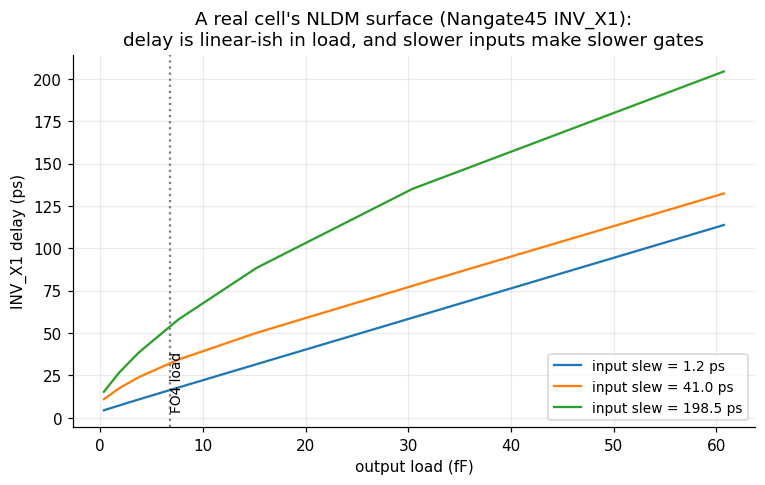

In [9]:
# The real thing: bilinear interpolation in the actual Nangate45 INV_X1 NLDM tables.
# Excerpted verbatim from NangateOpenCellLibrary_typical.lib (OpenROAD-flow-scripts).
# index_1 = input slew (ns), index_2 = output load (fF), values = delay / transition (ns).
SLEW = np.array([0.00117378, 0.00472397, 0.0171859, 0.0409838, 0.0780596, 0.130081, 0.198535])
LOAD = np.array([0.365616, 1.897810, 3.795620, 7.591250, 15.182500, 30.365000, 60.730000])

CELL_RISE = np.array([
    [0.00558495,0.00952547,0.0142069,0.0234111,0.0416815,0.0781322,0.150988],
    [0.00726612,0.0110313,0.0156990,0.0249513,0.0432921,0.0797973,0.152683],
    [0.0117593,0.0172024,0.0222810,0.0312450,0.0494226,0.0858830,0.158767],
    [0.0169697,0.0245178,0.0319657,0.0437440,0.0621260,0.0981372,0.170748],
    [0.0234502,0.0327927,0.0422113,0.0575993,0.0814250,0.118167,0.190083],
    [0.0313821,0.0424084,0.0535919,0.0721230,0.101629,0.146333,0.218093],
    [0.0409686,0.0535508,0.0664252,0.0878376,0.122423,0.176146,0.255965]])
CELL_FALL = np.array([
    [0.00334769,0.00529785,0.00763425,0.0122592,0.0214710,0.0398747,0.0766650],
    [0.00461096,0.00678237,0.00912396,0.0137631,0.0229885,0.0413991,0.0781923],
    [0.00565781,0.00963029,0.0133910,0.0192072,0.0284937,0.0468495,0.0836153],
    [0.00501217,0.0107451,0.0162361,0.0248924,0.0380191,0.0575991,0.0941587],
    [0.00228759,0.00977055,0.0169885,0.0284204,0.0459573,0.0721436,0.111006],
    [-0.00275926,0.00641510,0.0153503,0.0295626,0.0514378,0.0844139,0.133051],
    [-0.0102639,0.000468768,0.0110680,0.0280603,0.0542902,0.0939467,0.152970]])
RISE_TRANS = np.array([
    [0.00325898,0.00675403,0.0110850,0.0197517,0.0370834,0.0717177,0.141031],
    [0.00332094,0.00675485,0.0110858,0.0197475,0.0370819,0.0717179,0.141045],
    [0.00646300,0.00917631,0.0120151,0.0197468,0.0370798,0.0717347,0.141043],
    [0.0100688,0.0140883,0.0179745,0.0239390,0.0376321,0.0717196,0.141036],
    [0.0148442,0.0196692,0.0247509,0.0329193,0.0451557,0.0727075,0.141033],
    [0.0212043,0.0265195,0.0324007,0.0424452,0.0580872,0.0819889,0.141335],
    [0.0294730,0.0350265,0.0414593,0.0528699,0.0716272,0.0997522,0.149253]])
FALL_TRANS = np.array([
    [0.00146483,0.00307767,0.00507790,0.00907693,0.0170788,0.0330804,0.0650877],
    [0.00208078,0.00319162,0.00507788,0.00907788,0.0170769,0.0330758,0.0650897],
    [0.00453885,0.00619474,0.00782158,0.0104713,0.0171441,0.0330755,0.0650929],
    [0.00828209,0.0105589,0.0128211,0.0165329,0.0223384,0.0340626,0.0650908],
    [0.0134678,0.0163933,0.0192569,0.0239619,0.0314929,0.0430713,0.0667545],
    [0.0202479,0.0238387,0.0273358,0.0330037,0.0420922,0.0563711,0.0781250],
    [0.0288874,0.0330247,0.0371742,0.0438635,0.0544355,0.0712020,0.0970521]])

C_IN_INV = 1.700230    # fF, INV_X1 pin A capacitance -- also verbatim from the .lib


def nldm(table, slew, load):
    '''Bilinear interpolation, exactly what an STA engine does per timing arc.'''
    i = np.clip(np.searchsorted(SLEW, slew) - 1, 0, len(SLEW) - 2)
    j = np.clip(np.searchsorted(LOAD, load) - 1, 0, len(LOAD) - 2)
    fs = (slew - SLEW[i]) / (SLEW[i + 1] - SLEW[i])
    fl = (load - LOAD[j]) / (LOAD[j + 1] - LOAD[j])
    return ((1 - fs) * (1 - fl) * table[i, j]     + fs * (1 - fl) * table[i + 1, j]
            + (1 - fs) * fl     * table[i, j + 1] + fs * fl       * table[i + 1, j + 1])


def inv_delay(load_fF, n_iter=8):
    '''Self-consistent delay of an INV_X1 chain stage: iterate slew to fixpoint.'''
    slew = SLEW[0]
    for _ in range(n_iter):
        slew = 0.5 * (nldm(RISE_TRANS, slew, load_fF) + nldm(FALL_TRANS, slew, load_fF))
    return 0.5 * (nldm(CELL_RISE, slew, load_fF) + nldm(CELL_FALL, slew, load_fF)), slew


fo1_delay, _ = inv_delay(1 * C_IN_INV)
fo4_delay, fo4_slew = inv_delay(4 * C_IN_INV)
p45 = NODE["45 nm (Nangate45-class, 2008)"]
crayon_fo1 = 0.69 * p45["Ron"] * (p45["C_in"] + p45["C_par"])
print(f"From the REAL library:    FO1 = {fo1_delay*1e3:.1f} ps    FO4 = {fo4_delay*1e3:.1f} ps"
      f"   (self-consistent slew {fo4_slew*1e3:.1f} ps)")
print(f"Our crayon model in s.1:  FO1 = {crayon_fo1*1e12:.1f} ps    "
      f"FO4 ~ {p45['FO4']*1e12:.0f} ps  (textbook 45nm estimate: 15-20 ps)")
print("First-principles RC and foundry characterization agree to within ~30% -- and the")
print("table also encodes what RC ignores: slew dependence and rise/fall asymmetry.\n")

fig, ax = plt.subplots(figsize=(8, 4.4))
loads = np.linspace(LOAD[0], LOAD[-1], 200)
for si in [0, 3, 6]:
    d = [1e3 * 0.5 * (nldm(CELL_RISE, SLEW[si], L) + nldm(CELL_FALL, SLEW[si], L))
         for L in loads]
    ax.plot(loads, d, label=f"input slew = {SLEW[si]*1e3:.1f} ps")
ax.axvline(4 * C_IN_INV, ls=":", c="gray")
ax.annotate("FO4 load", xy=(4 * C_IN_INV, 5), fontsize=9, rotation=90)
ax.set_xlabel("output load (fF)")
ax.set_ylabel("INV_X1 delay (ps)")
ax.set_title("A real cell's NLDM surface (Nangate45 INV_X1):\ndelay is linear-ish in load, and slower inputs make slower gates")
ax.legend(fontsize=9)
plt.show()

### 6.5 Physical design: the netlist becomes geometry

Place & route turns the netlist into exact polygons. Tools: Cadence Innovus, Synopsys Fusion Compiler/ICC2,
open-source **OpenROAD**. Full flow for a 1–5M-instance block: **1–3 days** — the schedule-critical inner loop.
Sub-stages, each with one governing idea:

- **Floorplanning** — die shape, macro (SRAM) placement, pin locations. Quality here dominates everything
  downstream; a bad floorplan cannot be optimized away. Target 60–75% initial utilization so later steps have room.
- **Power planning** — build the power-delivery grid *first* (rings → straps → rails); budget: bump-to-cell IR
  drop under ~3–5% of VDD. The PDN eats 10–20% of routing resources. (At 2 nm-class, backside power delivery
  moves the grid to the wafer's back — a genuinely major change.)
- **Placement** — choose (x, y) for every cell, minimizing wirelength as a proxy for delay and power. Modern
  global placers are *analytical*: an electrostatics analogy (cells = charges, density = potential — the
  ePlace/RePlAce family, which is what OpenROAD uses) solved as continuous optimization, then legalized onto rows.
  The demo below shows the objective on a toy scale.
- **Clock tree synthesis (CTS)** — deliver the clock to 10⁵–10⁶ flops nearly simultaneously: skew targets
  10–50 ps, insertion delays 100–500 ps, structures from H-trees to meshes. The clock net is ~25–40% of dynamic
  power, hence clock gating everywhere.
- **Routing** — global (assign nets to regions) then detailed (exact tracks/vias on 12–18 metal layers, obeying
  thousands of design rules). Then post-route fixing: resize, hold buffers, crosstalk spacing, filler/decap.

What goes wrong: congestion hotspots that will not route, hold-fixing storms after CTS, blocks that oscillate
between fixing setup and breaking hold. Engineers stare at congestion heatmaps the way you stare at loss curves.


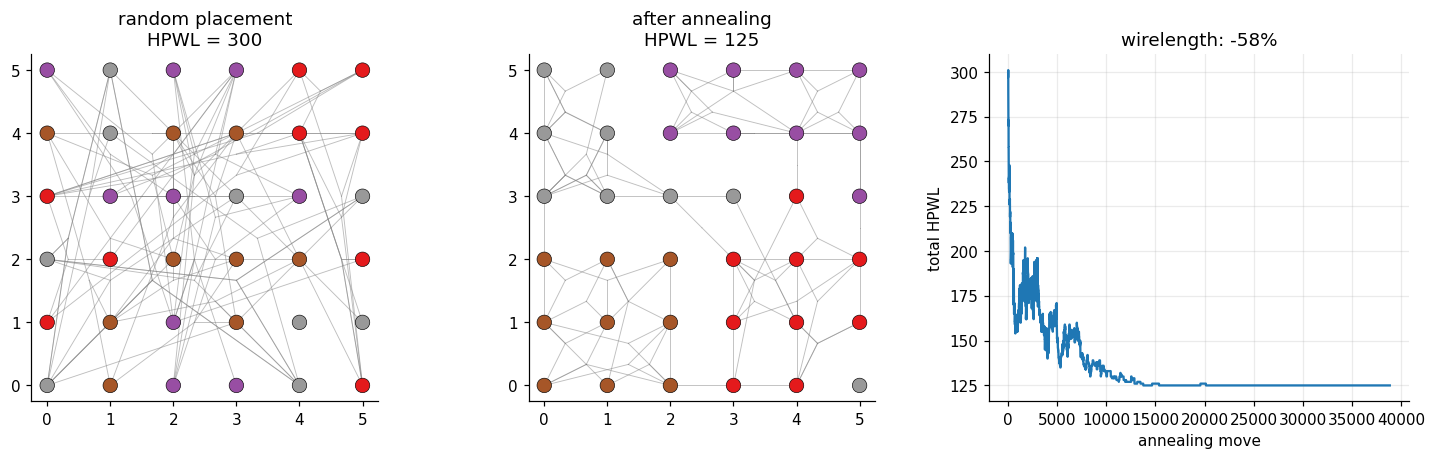

Shorter wires = less C = faster and lower power (sections 2 and 5). At real scale
(millions of cells) annealing is too slow; modern placers solve an electrostatics
field problem instead -- but the objective is the same picture you see here.


In [10]:
# Placement in miniature: simulated annealing minimizing half-perimeter wirelength
# (HPWL) -- the same objective class real analytical placers optimize continuously.
n_side, n_clusters = 6, 4
cells_per = n_side * n_side // n_clusters
cluster = np.repeat(np.arange(n_clusters), cells_per)

nets = []
for c in range(n_clusters):                       # local connectivity inside each cluster
    members = np.where(cluster == c)[0]
    for _ in range(12):
        nets.append(rng.choice(members, size=3, replace=False))
for _ in range(6):                                # a few global nets between clusters
    ca, cb = rng.choice(n_clusters, size=2, replace=False)
    nets.append(np.array([rng.choice(np.where(cluster == ca)[0]),
                          rng.choice(np.where(cluster == cb)[0])]))

cell2nets = [[] for _ in range(n_side * n_side)]
for ni, net in enumerate(nets):
    for c in net:
        cell2nets[c].append(ni)

def net_hpwl(net, pos):
    xy = pos[net]
    return np.ptp(xy[:, 0]) + np.ptp(xy[:, 1])

grid = np.array([(i % n_side, i // n_side) for i in range(n_side * n_side)], float)
perm = rng.permutation(n_side * n_side)           # random initial placement
pos = grid[perm].copy()
hpwl = sum(net_hpwl(net, pos) for net in nets)
hpwl0, pos0 = hpwl, pos.copy()

T0, T1, iters = 3.0, 0.01, 40000
history = []
for it in range(iters):
    T = T0 * (T1 / T0) ** (it / iters)
    a, b = rng.integers(0, n_side * n_side, 2)
    if a == b:
        continue
    touched = set(cell2nets[a]) | set(cell2nets[b])
    before = sum(net_hpwl(nets[ni], pos) for ni in touched)
    pos[[a, b]] = pos[[b, a]]
    after = sum(net_hpwl(nets[ni], pos) for ni in touched)
    dE = after - before
    if dE > 0 and rng.random() >= np.exp(-dE / T):
        pos[[a, b]] = pos[[b, a]]                 # reject: swap back
    else:
        hpwl += dE
    history.append(hpwl)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
for ax, P, ttl, h in [(axes[0], pos0, "random placement", hpwl0),
                      (axes[1], pos, "after annealing", hpwl)]:
    for net in nets:
        cx, cy = P[net].mean(axis=0)
        for c in net:
            ax.plot([P[c, 0], cx], [P[c, 1], cy], c="gray", lw=0.6, alpha=0.5, zorder=1)
    ax.scatter(P[:, 0], P[:, 1], c=cluster, cmap="Set1", s=90, zorder=2, edgecolors="k", lw=0.4)
    ax.set_title(f"{ttl}\nHPWL = {h:.0f}")
    ax.set_aspect("equal"); ax.grid(False)
axes[2].plot(history)
axes[2].set_xlabel("annealing move"); axes[2].set_ylabel("total HPWL")
axes[2].set_title(f"wirelength: -{(1 - hpwl/hpwl0)*100:.0f}%")
plt.tight_layout(); plt.show()

print("Shorter wires = less C = faster and lower power (sections 2 and 5). At real scale")
print("(millions of cells) annealing is too slow; modern placers solve an electrostatics")
print("field problem instead -- but the objective is the same picture you see here.")

### 6.6 Signoff, tapeout, and everything after

**Signoff** = independent, foundry-blessed checks by *different* tools than the ones that built the design
(checker ≠ doer):

- **Parasitic extraction** (Synopsys StarRC, Cadence Quantus): routed geometry → R and C of every net → `.spef`.
- **Signoff STA** (Synopsys **PrimeTime** — the de facto golden tool, Cadence Tempus): our §3 algorithm, at
  scale, across **dozens-to-100+ corner×mode scenarios** (process SS/TT/FF × voltage × temperature × extraction
  corners × functional/scan/sleep modes), with on-chip-variation models (flat OCV derates → AOCV → statistical
  POCV/LVF) and clock-path pessimism removal. A block is "closed" when WNS ≥ 0 everywhere.
- **Physical verification**: **DRC** (polygons obey the foundry's rule deck — >10,000 rules at 5/3 nm; Siemens
  **Calibre** is the golden standard, §7), **LVS** (extracted devices match the netlist), antenna rules, metal fill.
- **Power/electrical**: dynamic IR drop with real workload vectors (Ansys RedHawk-SC, Cadence Voltus),
  electromigration lifetime, power signoff (PrimePower) with activity from emulation.

The **timing-closure loop** is the flow's inner life: synthesize → place/CTS/route → extract → signoff STA →
ECO (small netlist patches: resize, buffer) → repeat. A block takes tens of full spins over months while the
RTL keeps changing under it (managed by freezes of increasing strictness). Since ~2021, RL-based flow
optimizers (Synopsys DSO.ai, Cadence Cerebrus) tune the hundreds of tool knobs per block — the industrial
cousin of learned PPA prediction: the loop is expensive, so search it smartly.

Also inserted along the way: **DFT** (design-for-test) — every flop becomes a scan flop so the tester can shift
in states and catch manufacturing defects (~99% stuck-at coverage target, 2–7% area cost); SRAMs get BIST +
fuse-programmable repair.

**Tapeout**: the final database is released to the foundry as **GDSII** (a 1978 Calma format! or OASIS) —
historically written to literal magnetic tape. The foundry then applies computational lithography (OPC:
pre-distorting polygons so diffraction prints them correctly — GPU farms) and writes the **masks** (~60–90
quartz reticles; ~$15–25M/set at 5 nm, $30–40M+ at 3/2 nm, estimates). One mask field = **26×33 mm = 858 mm²**,
the *reticle limit* — the hard ceiling on die size that pushed NVIDIA to two-die Blackwell.
Then: ~3–4 months in the fab (§9), wafer sort on ATE testers, packaging (flip-chip; 2.5D interposers — CoWoS;
3D hybrid bonding — AMD's V-Cache), final test, and **binning**: each die's measured fmax/Vmin turns the
process variation bell curve into a product stack (the same die ships as the flagship or the midrange SKU;
defective cores are fused off and sold as the 6-core part).


## 7. What Synopsys, Cadence and Siemens actually sell

The 30-second model: electronics ≈ $3T, built on **~$790B of semiconductors** (2025, a record year), designed
almost entirely with **~$21B of EDA software** (2025, ESD Alliance) from **three companies**. EDA is ~3% of
chip revenue and 100% of chip designs — the narrowest chokepoint in the stack. For an ML engineer: EDA vendors
are NVIDIA+CUDA+PyTorch combined — compiler, profiler, debugger, and the only certified runtime — except
closed-source, and the "hardware target" (the foundry process) certifies specific tool versions per node.

**Four revenue streams**: (1) time-based tool licenses (~60–70%; big customers sign 3-year, hundreds-of-$M
"remix" deals), (2) **semiconductor IP** (~30% of Synopsys: PCIe/DDR/HBM/SerDes/UCIe controllers and PHYs —
nobody redesigns a PCIe 6.0 PHY, a 2-year $50M analog project, when a silicon-proven one is licensable),
(3) emulation/prototyping hardware ($1M–$10M+ boxes), (4) services/cloud.

**The map** (each stage → who sells the tool; bold = the *signoff monopoly* everyone buys regardless of their
implementation flow):

| Flow stage | Synopsys | Cadence | Siemens EDA | Open source |
|---|---|---|---|---|
| Simulation | VCS | Xcelium | Questa | Verilator, Icarus |
| Debug | Verdi | Verisium | Visualizer | GTKWave, Surfer |
| Formal | VC Formal | **Jasper** | Questa Formal | SymbiYosys |
| Synthesis | Design Compiler / Fusion Compiler | Genus | (Aprisa flow) | Yosys + ABC |
| Place & route | ICC2 / Fusion Compiler | Innovus | Aprisa | OpenROAD |
| Timing signoff | **PrimeTime** | Tempus | — | OpenSTA |
| Power analysis | PrimePower | Voltus / Joules | PowerPro | (crude) |
| Extraction | StarRC | Quantus | Calibre xRC | OpenRCX |
| DRC/LVS signoff | IC Validator | Pegasus | **Calibre** | Magic, KLayout, netgen |
| DFT/ATPG | TestMAX | Modus | **Tessent** | (experimental) |
| Analog/custom | Custom Compiler | **Virtuoso + Spectre** | Tanner | xschem + ngspice |
| Emulation | ZeBu | Palladium | Veloce | — |
| AI layer | Synopsys.ai (DSO.ai…) | Cerebrus / AI Studio | Aprisa AI, Calibre AI | (research) |

Note the pattern: **each vendor owns one signoff monopoly** — Synopsys owns timing (PrimeTime), Siemens owns
physical verification (Calibre: foundries write their golden rule decks in Calibre's SVRF language *first*;
a false "DRC clean" costs a $30M mask set, so nobody accepts "mostly compatible"), Cadence owns analog
(Virtuoso/Spectre). A three-vendor flow — Genus/Innovus implementation + PrimeTime signoff + Calibre PV — is
completely normal. Scale (fiscal 2025): Synopsys $7.05B (incl. the **$35B Ansys acquisition**, closed July
2025 — RedHawk-SC power-integrity signoff plus multiphysics), Cadence $5.30B, Siemens EDA ~$2.2–2.5B (est.).

**What a seat costs** (order of magnitude — list prices are secret, everything is negotiated): simulator
$25–100K/seat-yr; formal $100–300K; synthesis $100–300K; **P&R $500K–$1M+**; emulator $1–10M/box. A 200-person
SoC team runs *thousands* of simulation licenses; big companies spend hundreds of $M/yr on EDA. Why so
expensive: a few hundred serious buyers worldwide must amortize thousands of R&D PhDs, and the pricing is
against catastrophic downside — one avoided respin pays for years of licenses.

**Why only three players**: 40 years of acquiring every successful point-tool startup; **foundry
certification** (TSMC brings up N2 jointly with the big three; the PDK names certified tool versions — an
uncertified tool means the foundry won't stand behind manufacturability), and 25 years of Tcl scripts and
trained engineers. The moat renews automatically every node, and no open-source project can cross it because
the process data itself is NDA'd.

**The AI arc** (your subfield's industrial context): 2020–23, black-box flow optimization (DSO.ai, Cerebrus:
RL over synthesis/P&R knobs — one engineer explores hundreds of flow configs); 2023–25, copilots + data lakes
(Verisium, Synopsys.ai Copilot); 2025–26, **agentic** (Cerebrus AI Studio orchestrating hierarchical SoC
implementation; Synopsys's autonomous verification agent claiming "up to 50× faster to validated RTL" at DAC
2026 — vendor numbers, treat accordingly). Every one of these loops is bottlenecked by the cost of one flow
evaluation — hours to days — which is precisely the bottleneck RTL-stage PPA prediction attacks.


## 8. The open-source stack — and the kimi-chip case study

Since 2020 a complete parallel universe exists: **Verilator** (compiles RTL to C++, 10–100× faster than
event-driven simulation — used industrially for regressions), **Icarus** (event-driven, for semantics),
**cocotb** (Python testbenches), **SymbiYosys** (formal), **Yosys + ABC** (synthesis), **OpenROAD** (the
serious open P&R engine, born from DARPA's IDEA program at UCSD: analytical placement, TritonCTS, TritonRoute,
OpenSTA), **OpenLane → LibreLane** (the productized flow; renamed after Efabless — the company that ran the
open shuttle program — shut down abruptly in March 2025; successors: **ChipFoundry.io**, ~$15K per 100
packaged sky130 chips, and **Tiny Tapeout**, ~€70 for a tile of a shared die, now mostly on IHP's process),
**Magic/KLayout/netgen** (layout, DRC, LVS).

Open PDKs made it real: **SkyWater sky130** (2020, Google: a full 130 nm process, Apache-2.0 — "git clone a
fab"), **GF180MCU**, **IHP SG13G2** (open 130 nm SiGe — 350/450 GHz transistors!), plus *predictive* research
PDKs that no fab accepts but every paper uses: **Nangate45/FreePDK45** (the one we read the Liberty tables
from) and **ASAP7**. If you train PPA models on public data, it is almost certainly generated by this stack —
full observability of every stage is exactly what encrypted commercial binaries deny you.

Honest capability line: the open flow takes RTL to *manufacturable* GDSII at 130–180 nm ($100–$15K tapeouts,
thousands of community chips), and to *realistic-but-fictional* GDSII on Nangate45/ASAP7 for research. It
cannot: touch any advanced node (no open PDK below 130 nm exists, or economically can), sign off timing a
foundry would accept, or match commercial QoR (folklore says 10–30% behind; vendor EULAs forbid publishing
benchmarks, which tells you something). The commercial stack sells *certainty at the leading edge*; the open
stack sells *access and observability*.

### 8.1 The kimi-chip story

Context: Moonshot's **Kimi K3** (a 2.8T-parameter open MoE model) shipped a proof-of-concept in its
announcement: the model designed, in a **48-hour autonomous run** on open EDA tools, an inference ASIC for a
~1M-parameter "nano" version of its own architecture — ~4 mm² on Nangate45, closing timing at **100 MHz**,
8,721 tok/s in simulation, 1.46M cells, INT4 MACs with fused dequantization, all weights in on-chip SRAM (the
fixed-size recurrent state of **KDA** — Kimi Delta Attention, a gated delta-rule linear attention with a
constant 128×128 per-head state instead of a growing KV cache — is what makes an all-SRAM chip feasible).

The [kimi-chip repo](https://github.com/physical-intuition/kimi-chip) (MIT; authored, per its companion blog,
by a Claude agent) re-derives that accelerator with **Yosys + OpenROAD + Nangate45** and beats it ~10× using an
LLM **meta-harness**: **Y iterations** are RTL attempts inside a fixed diagnostic harness (write RTL →
testbench regression → synthesis → P&R → collect fmax/WNS/area → diagnose → repeat); **X generations** rewrite
the *harness itself* — the failure taxonomy and fix-proposal strategy. Termination rule, worth framing:

> **"A flat row means the harness is wrong, not the RTL."**

When several Y's plateau despite RTL changes, iterating harder inside the framework is wasted compute (inner
loop = SGD steps; outer loop = changing the optimizer when the loss flatlines). Headline numbers, with the
repo's own caveats: MAC array peaked at **1047 MHz** (X5); the full KDA dataflow peaked at **900 MHz** (X7-Y4),
with the final post-route iteration closing at 728 MHz. Academic PDK, no commercial signoff, and the repo's own
audit calls the implementation ~50% functionally complete — *compute fragments, not a chip* — but the
methodology arc is real and the numbers below are from its committed build logs.

Verification lessons the project logged, which every DV engineer will recognize: the design passed timing and
DRC while containing a double-accumulation bug and an overflow at K=32 — **"clean synthesis doesn't mean
correct design"** — caught only by adversarial testbenches (signed extrema, fold-boundary K values, mid-run
resets). And the harness enforced *"no fabricated metrics — executable evidence only."*

The full trial matrix is a beautiful miniature of what §6's flow feels like from inside — and, for your
purposes, a tiny labeled **RTL → post-route PPA dataset** generated by exactly the tools academic PPA datasets
use. Let's plot it.


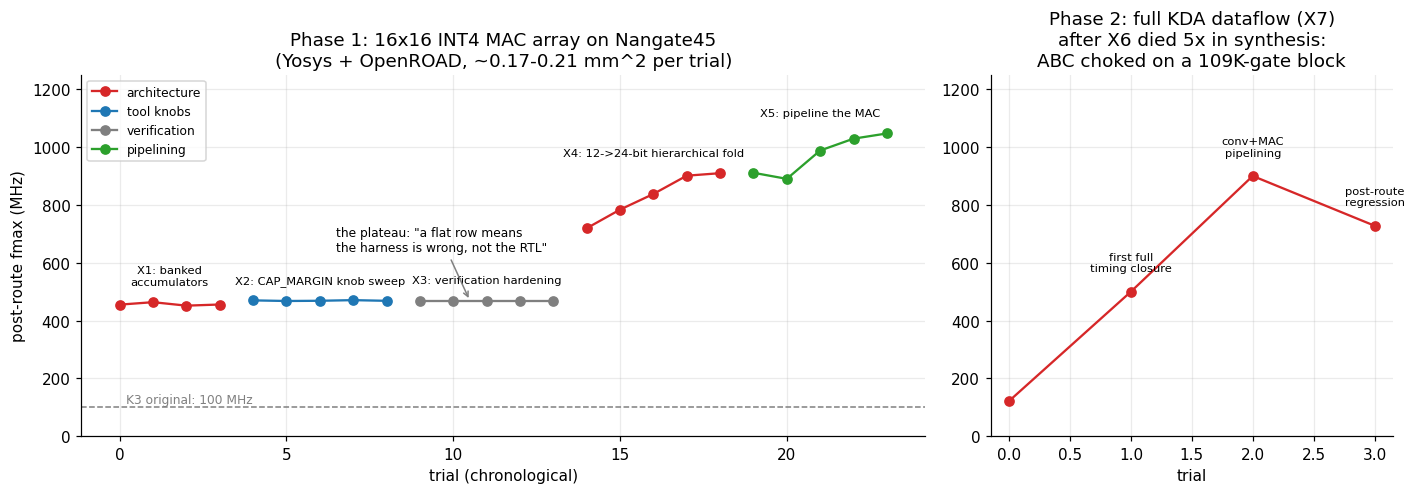

change type                         effect on fmax                   
---------------------------------------------------------------------
tool-knob tuning (X2)               +/- ~1%                          
verification-only changes (X3)      exactly 0%  (5 identical results)
architecture: narrow the loop (X4)  +94%  (468 -> 910 MHz)           
pipelining registers (X5)           +15%  (910 -> 1047 MHz)          

Each (X,Y) point is a labeled (RTL -> post-route fmax/area) sample from the exact
Yosys/OpenROAD/Nangate45 stack academic PPA datasets use. Note the moral for
prediction: a ONE-LINE RTL edit (register one 8-bit product) moved post-route fmax
10-15%, while wholesale testbench rewrites moved it 0.000%. Text similarity is not
PPA similarity -- structure is what matters. (Also: one open-flow iteration on a
~0.2 mm^2 block runs in minutes-to-an-hour on one machine -- cheap enough to
generate datasets, which is why this stack is where ML-for-EDA research lives.)


In [11]:
# The kimi-chip X/Y matrix: post-route fmax per trial (from the repo's build logs).
# Category = what kind of change each harness generation made.
trials = [
    # (X-gen, label, fmax_MHz list, category)
    ("X1", "banked\naccumulators", [455.0, 463.49, 451.475, 455.449], "architecture"),
    ("X2", "CAP_MARGIN knob sweep", [469.734, 467.594, 468.346, 470.547, 468.201], "tool knobs"),
    ("X3", "verification hardening", [468.201] * 5, "verification"),
    ("X4", "12->24-bit hierarchical fold", [719.14, 783.569, 837.683, 900.93, 909.621], "architecture"),
    ("X5", "pipeline the MAC", [911, 890, 988, 1029, 1047], "pipelining"),
]
colors = {"architecture": "#d62728", "tool knobs": "#1f77b4",
          "verification": "#7f7f7f", "pipelining": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [2.1, 1]})
i = 0
seen = set()
for xgen, label, vals, cat in trials:
    idx = np.arange(i, i + len(vals))
    axes[0].plot(idx, vals, "o-", c=colors[cat],
                 label=cat if cat not in seen else None)
    seen.add(cat)
    axes[0].annotate(f"{xgen}: {label}", xy=(idx.mean(), max(vals)),
                     xytext=(idx.mean(), max(vals) + 60), ha="center", fontsize=7.5)
    i += len(vals)
axes[0].axhline(100, ls="--", c="gray", lw=1)
axes[0].annotate("K3 original: 100 MHz", xy=(0.2, 115), fontsize=8, c="gray")
axes[0].annotate('the plateau: "a flat row means\nthe harness is wrong, not the RTL"',
                 xy=(10.5, 468), xytext=(6.5, 640),
                 arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8)
axes[0].set_xlabel("trial (chronological)")
axes[0].set_ylabel("post-route fmax (MHz)")
axes[0].set_ylim(0, 1250)
axes[0].set_title("Phase 1: 16x16 INT4 MAC array on Nangate45\n(Yosys + OpenROAD, ~0.17-0.21 mm^2 per trial)")
axes[0].legend(fontsize=8, loc="upper left")

x7 = [122, 500, 900, 728]
axes[1].plot(range(len(x7)), x7, "o-", c="#d62728")
for j, (v, note) in enumerate(zip(x7, ["", "first full\ntiming closure", "conv+MAC\npipelining",
                                       "post-route\nregression"])):
    axes[1].annotate(note, xy=(j, v), xytext=(j, v + 70), ha="center", fontsize=7.5)
axes[1].set_ylim(0, 1250)
axes[1].set_xlabel("trial")
axes[1].set_title("Phase 2: full KDA dataflow (X7)\nafter X6 died 5x in synthesis:\nABC choked on a 109K-gate block")
plt.tight_layout()
plt.show()

# The punchline table: how much each *kind* of change moved fmax.
show_table(["change type", "effect on fmax"],
           [["tool-knob tuning (X2)", "+/- ~1%"],
            ["verification-only changes (X3)", "exactly 0%  (5 identical results)"],
            ["architecture: narrow the loop (X4)", "+94%  (468 -> 910 MHz)"],
            ["pipelining registers (X5)", "+15%  (910 -> 1047 MHz)"]])
print("\nEach (X,Y) point is a labeled (RTL -> post-route fmax/area) sample from the exact")
print("Yosys/OpenROAD/Nangate45 stack academic PPA datasets use. Note the moral for")
print("prediction: a ONE-LINE RTL edit (register one 8-bit product) moved post-route fmax")
print("10-15%, while wholesale testbench rewrites moved it 0.000%. Text similarity is not")
print("PPA similarity -- structure is what matters. (Also: one open-flow iteration on a")
print("~0.2 mm^2 block runs in minutes-to-an-hour on one machine -- cheap enough to")
print("generate datasets, which is why this stack is where ML-for-EDA research lives.)")

## 9. Fabrication: printing with light, paying with yield

**A foundry is a printing press for atoms.** The fabless designer delivers polygons (GDSII); the foundry
(TSMC ~72% of pure-play revenue as of early 2026; Samsung ~6.5%, SMIC ~5%, Intel Foundry ramping 18A) turns
each of ~70–100 layers into a photomask and prints wafers — ~1,000+ process steps, **~3–4 months** per wafer
(≈1–1.5 days per mask layer). The designer never touches a wafer; the interface is *entirely files*: the
**PDK** (design rules, SPICE models, the .lib/.lef/GDS cell libraries we've been using) going one way, GDSII
coming back. A leading-edge fab costs $20–30B.

**Lithography** is the heartbeat. Resolution follows Rayleigh: $CD = k_1 \lambda / NA$.
- **DUV immersion** (λ=193 nm, NA=1.35): ~76–80 nm single-exposure pitch; below that, multi-patterning
  (2–4 masks per layer) — 7 nm was the DUV endgame (and is SMIC's ceiling today, by export control).
- **EUV** (λ=13.5 nm, NA=0.33): tin droplets hit by a 25–40 kW laser 50,000×/s make plasma at ~500,000 K; all
  optics are Mo/Si Bragg *mirrors* (~70% reflective — after ~11 bounces, ~1–2% of the light survives);
  ~$180–235M per machine, ~20 EUV layers at N3/N2. **ASML is a 100% monopoly.**
- **High-NA EUV** (NA=0.55): ~$380–400M per tool; Intel installed the first production unit (Dec 2025, for
  14A); the exposure field *halves* to 429 mm² — one more force pushing toward chiplets. TSMC is publicly
  sitting it out until ~A10 (~2030).

**Node names measure nothing.** "3 nm" has a ~48 nm gate pitch and ~23 nm metal pitch; the smallest real
feature (~5 nm nanosheet) is ~9 silicon unit cells. What actually changed at "2 nm": GAA nanosheets (TSMC N2 in
volume since Q4 2025 — first product: the A20 Pro in the iPhone 18 Pro, Sept 2026; Intel 18A RibbonFET +
PowerVia backside power since 2025). Wafer prices (trade-press estimates — foundries publish no price lists):
28 nm ≈ $3K, 7 nm ≈ $9–10K, 5 nm ≈ $17K, 3 nm ≈ **$25–27K** (2025–26, AI-demand hikes), **N2 = ~$30K** (set
Oct 2025, booked to 2028).

**Yield is where the money is won.** Defects land ~randomly at density $D_0$ (defects/cm²; TSMC N5 launched at
≈0.10, mature nodes reach ≈0.05; N2's ramp is reportedly the best in company history). A die containing one
killer defect is dead, so under the simplest (Poisson) model $Y = e^{-A D_0}$: **yield falls exponentially with
die area.** That one exponential explains AMD's chiplet strategy, harvested SKUs, and why nobody builds
reticle-limit dies unless they are NVIDIA. The next two cells do the arithmetic.


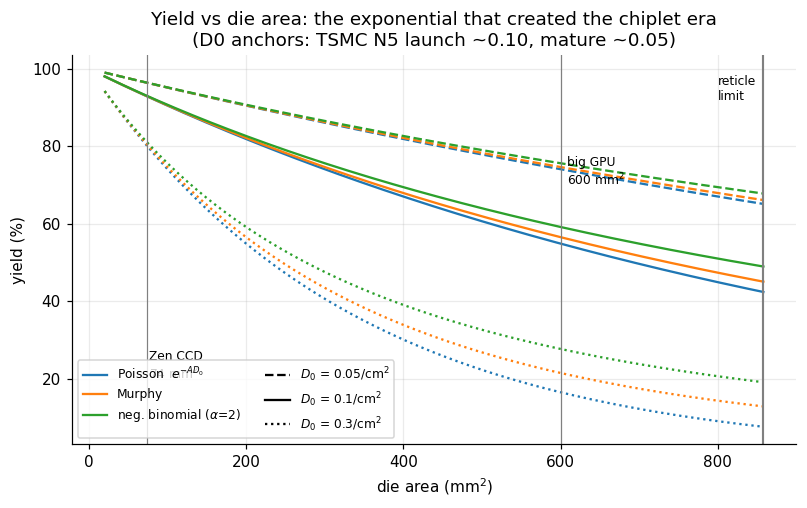

die                  dies/wafer  yield % (D0=0.1)  good dies/wafer
------------------------------------------------------------------
Zen CCD (74 mm^2)    841.5       92.9              781.4          
monolithic 600 mm^2  86.5        54.9              47.5           


In [12]:
# Dies per wafer, and three classical yield models.
WAFER_R = 147.0            # mm usable radius (300mm wafer, ~3mm edge exclusion)
USABLE_AREA = np.pi * WAFER_R**2          # ~67,900 mm^2


def dies_per_wafer(A_mm2):
    '''Standard estimate incl. the circular-edge loss term.'''
    return USABLE_AREA / A_mm2 - np.pi * 2 * WAFER_R / np.sqrt(2 * A_mm2)


def yield_poisson(A_mm2, D0):          # D0 in defects/cm^2
    return np.exp(-A_mm2 / 100 * D0)

def yield_murphy(A_mm2, D0):
    AD = A_mm2 / 100 * D0
    return ((1 - np.exp(-AD)) / AD) ** 2

def yield_negbin(A_mm2, D0, alpha=2.0):   # Stapper; alpha = defect clustering
    return (1 + A_mm2 / 100 * D0 / alpha) ** (-alpha)


A = np.linspace(20, 858, 300)             # up to the reticle limit
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for D0, ls in [(0.05, "--"), (0.10, "-"), (0.30, ":")]:
    ax.plot(A, yield_poisson(A, D0) * 100, "C0", ls=ls)
    ax.plot(A, yield_murphy(A, D0) * 100, "C1", ls=ls)
    ax.plot(A, yield_negbin(A, D0) * 100, "C2", ls=ls)
for c, lab in [("C0", "Poisson  $e^{-AD_0}$"), ("C1", "Murphy"), ("C2", "neg. binomial ($\\alpha$=2)")]:
    ax.plot([], [], c, label=lab)
for D0, ls in [(0.05, "--"), (0.10, "-"), (0.30, ":")]:
    ax.plot([], [], "k", ls=ls, label=f"$D_0$ = {D0}/cm$^2$")
ax.axvline(74, c="gray", lw=0.8); ax.annotate("Zen CCD\n74 mm$^2$", xy=(76, 20), fontsize=8)
ax.axvline(600, c="gray", lw=0.8); ax.annotate("big GPU\n600 mm$^2$", xy=(608, 70), fontsize=8)
ax.axvline(858, c="gray", lw=1.4); ax.annotate("reticle\nlimit", xy=(800, 92), fontsize=8)
ax.set_xlabel("die area (mm$^2$)")
ax.set_ylabel("yield (%)")
ax.set_title("Yield vs die area: the exponential that created the chiplet era\n"
             "(D0 anchors: TSMC N5 launch ~0.10, mature ~0.05)")
ax.legend(fontsize=8, ncol=2)
plt.show()

rows = []
for A_die, name in [(74, "Zen CCD (74 mm^2)"), (600, "monolithic 600 mm^2")]:
    dpw = dies_per_wafer(A_die)
    y = yield_poisson(A_die, 0.10)
    rows.append([name, dpw, y * 100, dpw * y])
show_table(["die", "dies/wafer", "yield % (D0=0.1)", "good dies/wafer"], rows, floatfmt="{:.1f}")

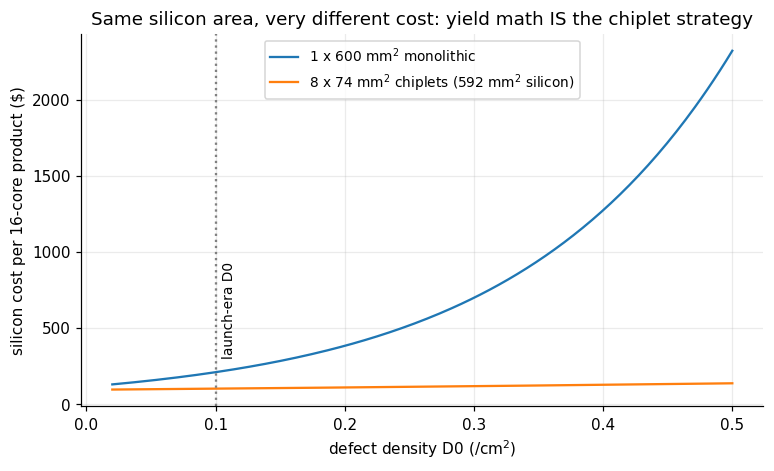

At D0 = 0.1/cm^2 on ~$10k N7 wafers [est]:
  monolithic 600 mm^2: $211
  8 chiplets:          $102   (2.1x cheaper)

Plus: the I/O die goes on a node ~4x cheaper per mm^2; one CCD design serves
laptop through EPYC (NRE amortization, section 10); and a CCD with one dead core
ships as the 6-core SKU. The taxes: packaging (CoWoS et al.), ~0.3-0.5 pJ/bit and
~+10 ns for die-to-die links vs on-die wires, and known-good-die testing.


In [13]:
# The chiplet argument, in dollars: reproduce AMD's ~2x cost claim.
# 16-core product: either one 600 mm^2 monolithic die (N7), or 8 x 74 mm^2 CCDs.
WAFER_PRICE_N7 = 10_000     # $ [est]; N5 ~ $17k

def cost_per_good_die(A_mm2, D0, wafer_price):
    return wafer_price / (dies_per_wafer(A_mm2) * yield_poisson(A_mm2, D0))

D0s = np.linspace(0.02, 0.5, 200)
mono = cost_per_good_die(600, D0s, WAFER_PRICE_N7)
chiplet = 8 * cost_per_good_die(74, D0s, WAFER_PRICE_N7)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(D0s, mono, label="1 x 600 mm$^2$ monolithic")
ax.plot(D0s, chiplet, label="8 x 74 mm$^2$ chiplets (592 mm$^2$ silicon)")
ax.axvline(0.10, ls=":", c="gray")
ax.annotate("launch-era D0", xy=(0.105, 320), fontsize=9, rotation=90)
ax.set_xlabel("defect density D0 (/cm$^2$)")
ax.set_ylabel("silicon cost per 16-core product ($)")
ax.set_title("Same silicon area, very different cost: yield math IS the chiplet strategy")
ax.legend(fontsize=9)
plt.show()

d = 0.10
print(f"At D0 = {d}/cm^2 on ~$10k N7 wafers [est]:")
print(f"  monolithic 600 mm^2: ${cost_per_good_die(600, d, WAFER_PRICE_N7):.0f}")
print(f"  8 chiplets:          ${8 * cost_per_good_die(74, d, WAFER_PRICE_N7):.0f}"
      f"   ({cost_per_good_die(600, d, WAFER_PRICE_N7) / (8 * cost_per_good_die(74, d, WAFER_PRICE_N7)):.1f}x cheaper)")
print("\nPlus: the I/O die goes on a node ~4x cheaper per mm^2; one CCD design serves")
print("laptop through EPYC (NRE amortization, section 10); and a CCD with one dead core")
print("ships as the 6-core SKU. The taxes: packaging (CoWoS et al.), ~0.3-0.5 pJ/bit and")
print("~+10 ns for die-to-die links vs on-die wires, and known-good-die testing.")

## 10. Economics: Moore's law, the cost-per-transistor stall, and who can play

Moore's observation (1965/1975) was always economic: the number of transistors at *minimum cost per
transistor* doubles on a cadence. The doubling has held for 50+ years (next cell: fitted rate ~2.0
years) — but note the modern data points quietly cheat with multi-die packages, and the *cost* half of the
law broke first: since ~28 nm, wafer-price growth (~2× per two nodes) roughly cancels density growth, so cost
per transistor has been flat-ish for a decade. That flattening — not physics — is why analog, RF and
automotive parts stay on 28–65 nm forever, and why "just port it to the next node" stopped being free.

The other exponential is **NRE** (non-recurring engineering). Design cost by node (IBS estimates, widely
quoted, methodology debated): $51M (28 nm) → $298M (7 nm) → $542M (5 nm) → **~$725M (2 nm)** — plus a
$40–50M mask set. Amortization decides who can play: the last cell of this section computes the volume you
need before the leading edge makes sense.


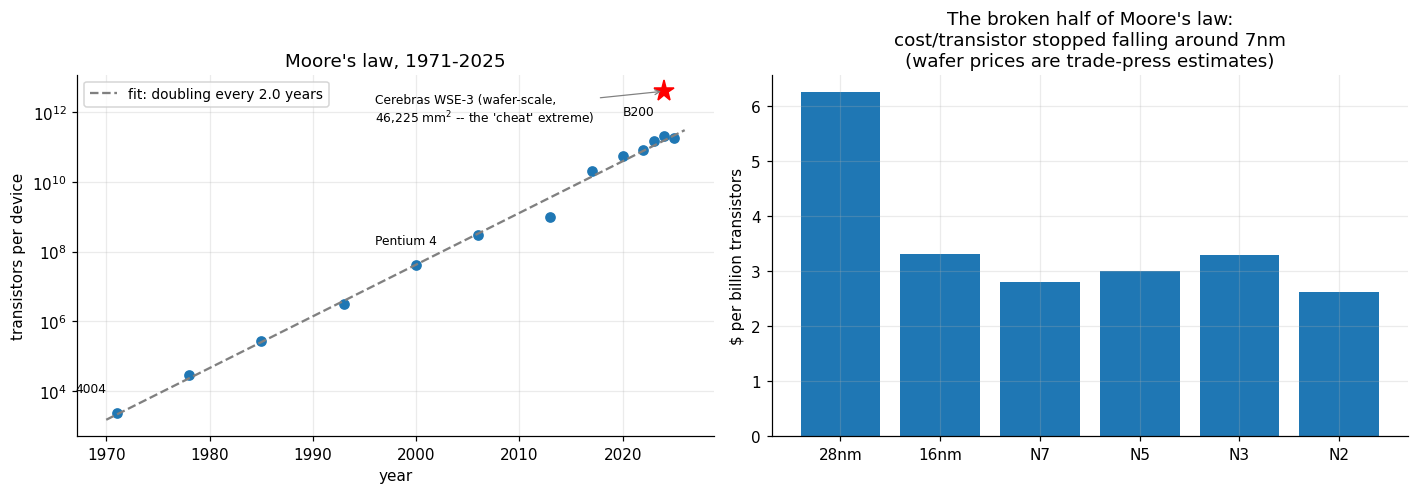

node  $/wafer [est]  MTr/mm^2  $/Gtransistor
--------------------------------------------
28nm  2750           12        6.3          
16nm  4000           33        3.3          
N7    9350           91        2.8          
N5    17000          155       3.0          
N3    26000          215       3.3          
N2    30000          313       2.6          


In [14]:
# Moore's law fit + cost per transistor by node.
moore = [  # (year, name, transistors)
    (1971, "4004", 2_300), (1978, "8086", 29_000), (1985, "386", 275_000),
    (1993, "Pentium", 3.1e6), (2000, "Pentium 4", 42e6), (2006, "Core 2 Duo", 291e6),
    (2013, "Apple A7", 1e9), (2017, "V100", 21.1e9), (2020, "A100", 54.2e9),
    (2022, "H100", 80e9), (2023, "MI300X", 153e9), (2024, "B200", 208e9),
    (2025, "M3 Ultra", 184e9),
]
years = np.array([m[0] for m in moore], float)
trans = np.array([m[2] for m in moore], float)
slope, intercept = np.polyfit(years, np.log2(trans), 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].semilogy(years, trans, "o")
yy = np.linspace(1970, 2026, 100)
axes[0].semilogy(yy, 2 ** (slope * yy + intercept), "--", c="gray",
                 label=f"fit: doubling every {1/slope:.1f} years")
axes[0].semilogy([2024], [4e12], "r*", ms=14)
axes[0].annotate("Cerebras WSE-3 (wafer-scale,\n46,225 mm$^2$ -- the 'cheat' extreme)",
                 xy=(2024, 4e12), xytext=(1996, 5e11), fontsize=8,
                 arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
for y, n, t in [moore[0], moore[4], moore[11]]:
    axes[0].annotate(n, xy=(y, t), xytext=(y - 4, t * 4), fontsize=8)
axes[0].set_xlabel("year"); axes[0].set_ylabel("transistors per device")
axes[0].set_title("Moore's law, 1971-2025")
axes[0].legend(fontsize=9)

# Cost per billion transistors: wafer price / (density x utilization x usable area x yield).
# Density = peak HD-library MTr/mm^2 [teardown estimates]; real chips achieve ~50-70% of it.
nodes = [  # (name, $/wafer [est, 2025-26-ish], peak MTr/mm^2 [approx])
    ("28nm", 2_750, 12), ("16nm", 4_000, 33), ("N7", 9_350, 91),
    ("N5", 17_000, 155), ("N3", 26_000, 215), ("N2", 30_000, 313),
]
cost_per_gtr = []
for name, wp, dens in nodes:
    tr_per_wafer = dens * 1e6 * USABLE_AREA * 0.6 * 0.90    # 60% util, 90% yield
    cost_per_gtr.append(wp / (tr_per_wafer / 1e9))
axes[1].bar([n[0] for n in nodes], cost_per_gtr, color="#1f77b4")
axes[1].set_ylabel("$ per billion transistors")
axes[1].set_title("The broken half of Moore's law:\ncost/transistor stopped falling around 7nm\n(wafer prices are trade-press estimates)")
plt.tight_layout()
plt.show()

show_table(["node", "$/wafer [est]", "MTr/mm^2", "$/Gtransistor"],
           [[n, w, d, c] for (n, w, d), c in zip(nodes, cost_per_gtr)], floatfmt="{:.1f}")

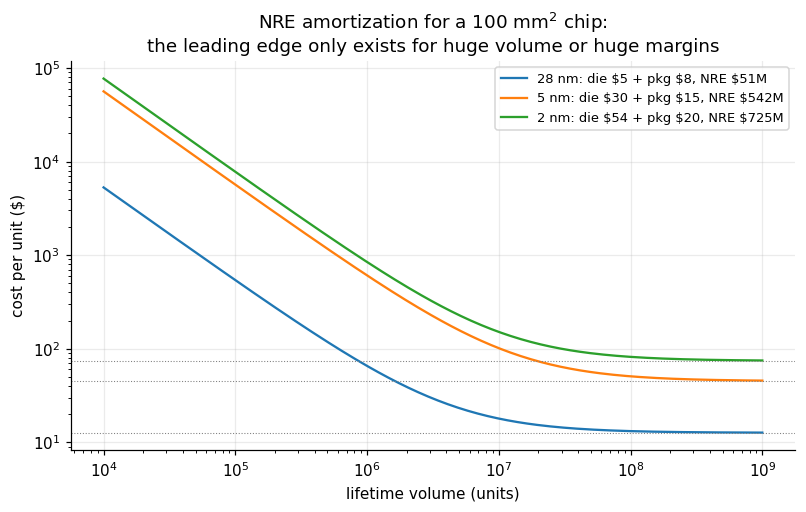

node   100K units  1M units  10M units  100M units
--------------------------------------------------
28 nm  $541        $65       $18        $13       
5 nm   $5,667      $607      $101       $51       
2 nm   $7,774      $844      $151       $82       

At 1M units a 2nm chip costs ~$800/unit before profit; at 100M, ~$80 -- of which
only ~$8 is amortized NRE; the rest is silicon, yield, and packaging.
Hence: only ~a dozen companies tape out leading-edge (phones, hyperscalers, AI
accelerators with 70% margins) -- and everyone else buys chiplets, IP, and older nodes.


In [15]:
# NRE amortization: unit cost vs volume. Who can afford which node?
# die: a 100 mm^2 chip on each node; package+test assumed $8/$15/$20 [assumption].
scenarios = [  # name, NRE $, mask set $, wafer $, D0, pkg+test $
    ("28 nm", 51.3e6, 1.5e6, 2_750, 0.03, 8),
    ("5 nm", 542.2e6, 20e6, 17_000, 0.08, 15),
    ("2 nm", 725e6, 45e6, 30_000, 0.10, 20),
]
V = np.logspace(4, 9, 200)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for name, nre, masks, wp, d0, pkg in scenarios:
    die = cost_per_good_die(100, d0, wp)
    unit = (nre + masks) / V + die + pkg
    ax.loglog(V, unit, label=f"{name}: die ${die:.0f} + pkg ${pkg}, NRE ${nre/1e6:.0f}M")
    ax.axhline(die + pkg, ls=":", lw=0.7, c="gray")
ax.set_xlabel("lifetime volume (units)")
ax.set_ylabel("cost per unit ($)")
ax.set_title("NRE amortization for a 100 mm$^2$ chip:\nthe leading edge only exists for huge volume or huge margins")
ax.legend(fontsize=8.5)
plt.show()

rows = []
for name, nre, masks, wp, d0, pkg in scenarios:
    die = cost_per_good_die(100, d0, wp)
    rows.append([name] + [f"${(nre + masks) / v + die + pkg:,.0f}"
                          for v in [1e5, 1e6, 1e7, 1e8]])
show_table(["node", "100K units", "1M units", "10M units", "100M units"], rows)
print("\nAt 1M units a 2nm chip costs ~$800/unit before profit; at 100M, ~$80 -- of which")
print("only ~$8 is amortized NRE; the rest is silicon, yield, and packaging.")
print("Hence: only ~a dozen companies tape out leading-edge (phones, hyperscalers, AI");
print("accelerators with 70% margins) -- and everyone else buys chiplets, IP, and older nodes.")

## 11. Where RTL-stage PPA estimation fits (taking this to your real problem)

Look back at the flow with surrogate-model eyes:

- **The industry already runs on learned surrogates.** The `.lib` NLDM tables you interpolated in §6.4 *are*
  characterized surrogates of SPICE; wireload models were (bad) statistical surrogates of placement; AOCV
  tables are surrogates of Monte-Carlo SPICE. Every stage boundary is a prediction problem: the performance
  model predicts RTL IPC; synthesis predicts post-route timing; placement predicts routed congestion.
  RTL-stage PPA estimation is the next surrogate in a long lineage — predict from RTL what you'd otherwise
  learn from a 2–12 h synthesis probe or a 1–3 day P&R probe.
- **The economics is the same as NAS proxies.** The design space at RTL (µarch parameters × constraints ×
  floorplans) is combinatorial and each evaluation costs hours-to-days of licensed compute (§7's seat prices
  make each probe literally expensive). A trustworthy seconds-scale RTL→PPA predictor collapses the outer
  loop — which is why the vendors sell exactly this (Cadence Joules claims ~15% accuracy vs signoff power from
  RTL; Synopsys PrimePower RTL; DSO.ai/Cerebrus wrap search around the whole flow).
- **The labels are noisy and conditional — define your dataset carefully.** Re-running the same RTL through
  the same flow with a different seed or tool version moves WNS by several percent and area by 1–3% — a label
  noise floor your evaluation must respect. And "the" PPA of an RTL block doesn't exist: labels are
  conditional on corner, constraints, utilization, and flow stage (post-synthesis vs post-route). This is why
  papers disagree wildly, and why dataset definition is half the research problem.
- **The kimi X/Y matrix (§8) is a miniature of both the promise and the difficulty**: verification rewrites
  moved fmax 0.000% while a one-line structural edit moved it 15% and an architectural change 94%. Models that
  read RTL as *text* will conflate those; models that read structure (the bit-level operator graphs of
  MasterRTL, the cone-level features of RTL-Timer/SNS, the multimodal fusion of CircuitFusion) have a chance.
  And the open stack that generated those labels — Yosys/OpenROAD on Nangate45, plus sky130 and ASAP7 — is the
  same one behind essentially every public PPA dataset (CircuitNet et al.), for the reason §8 gave: it's the
  only flow you can observe and afford to run thousands of times.
- **Tile-level is a deliberate altitude.** §6.1's hierarchy puts the tile (50K–5M instances) at the unit of
  physical-design ownership — big enough that its PPA is a business-relevant number (one engineer-month per
  P&R spin), small enough that cross-design generalization is conceivable. That's the altitude of SNS
  (whole-core PPA, 100–1000× faster than synthesis) and APOLLO (per-cycle power of Arm cores from <0.05% of
  RTL signals) in your reading list.

The companion syllabus for going deep on all of this lives in
[reading_list.md](reading_list.md) (68 papers; start with the Shift-Left survey → MasterRTL → SNS/SNSv2 →
RTL-Timer → CircuitSeer). This notebook is the "why the labels behave that way" prequel to those papers.


## 12. References

**Textbooks / canon**
- Weste & Harris, *CMOS VLSI Design*, 4th ed. — the standard text (logical effort, FO4, flop internals).
- Rabaey, Chandrakasan & Nikolić, *Digital Integrated Circuits* — delay/power derivations.
- Sutherland, Sproull & Harris, *Logical Effort* (1999).
- Dennard et al., "Design of Ion-Implanted MOSFETs…", IEEE JSSC 1974 — the scaling paper.
- Horowitz, "Computing's Energy Problem (and what we can do about it)", ISSCC 2014 — the energy table.
- Esmaeilzadeh et al., "Dark Silicon and the End of Multicore Scaling", ISCA 2011.
- Magen et al., "Interconnect-Power Dissipation in a Microprocessor", SLIP 2004 — the ~50%-wires measurement.
- Ho, Mai & Horowitz, "The Future of Wires", Proc. IEEE 2001.
- Kuon & Rose, "Measuring the Gap Between FPGAs and ASICs", IEEE TCAD 2007 — the 35×/3.4×/14× numbers.

**The inspiration**
- [physical-intuition/kimi-chip](https://github.com/physical-intuition/kimi-chip) — the repo this notebook
  replays in §8 (README, `experiments/MATRIX_PROGRESS.md`, `KIMI_SPEC.md`, `audit/docs/GAP_ANALYSIS.md`).
- Its companion blog: "Meta harness makes 10× better Kimi K3 chip" (luoluo.ai/blog/kimi-k3).

**Tools and data used above**
- Nangate45 / FreePDK45 open cell library, as shipped in
  [OpenROAD-flow-scripts](https://github.com/The-OpenROAD-Project/OpenROAD-flow-scripts) — source of the
  Liberty (.lib) excerpts and NLDM tables in §6.4.
- [Yosys](https://github.com/YosysHQ/yosys), [OpenROAD](https://theopenroad.org),
  [LibreLane](https://librelane.readthedocs.io), [SkyWater sky130](https://github.com/google/skywater-pdk),
  [ASAP7](https://github.com/The-OpenROAD-Project/asap7).

**Industry numbers** (all flagged in-text as estimates where applicable)
- Siemens EDA / Wilson Research Group Functional Verification Study, 2024 edition (first-silicon success,
  debug share).
- CSET, "AI Chips: What They Are and Why They Matter" (2020) — the classic wafer-price baseline; 2025–26
  wafer/N2 pricing from trade press (TechNode, Digitimes). IBS design-cost-per-node estimates as reproduced in
  trade press. TrendForce quarterly foundry market shares (Q1 2026). ESD Alliance EDA market statistics.
- TechInsights / WikiChip teardown data for pitches and transistor densities.

**Next door in this series**: [outlier_detection_from_first_principles.ipynb](../../ML/outlier_detection/outlier_detection_from_first_principles.ipynb)
and friends — same house style, different universe. The PPA-estimation syllabus: [reading_list.md](reading_list.md).
